# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [22]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
import scipy.stats as stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [5]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [ ]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
## file_1 =
# Chargement des données


In [6]:
## TODO : make into a dataframe called df

df = pd.read_csv("Churn_Modelling.csv")

In [7]:
## TODO : output the first 5 lines

print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

# Informations complémentaires sur le dataset

In [6]:
# Infos générales
print("\nInfos sur le dataset:")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives:")
print(df.describe())

# Dimensions du dataset
print("\nDimensions:", df.shape)


Infos sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Statistiques descriptives:
         RowNumber    CustomerId   Cre

In [8]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively

# Création des DataFrames df_0 (clients n'ayant pas quitté) et df_1 (clients ayant quitté)
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

print("Dimensions de df_0 (clients n'ayant pas quitté la banque) :", df_0.shape)
print("Dimensions de df_1 (clients ayant quitté la banque) :", df_1.shape)

Dimensions de df_0 (clients n'ayant pas quitté la banque) : (7963, 14)
Dimensions de df_1 (clients ayant quitté la banque) : (2037, 14)


# Observations 

Le dataset a été correctement scindé en deux groupes distincts basés sur la variable Exited.

> df_0 (Clients n'ayant pas quitté) : Contient 7963 observations.

> df_1 (Clients ayant quitté) : Contient 2037 observations.

Cette répartition met en évidence une dissymétrie significative dans les classes de la variable cible Exited. Environ 20,37% des clients ont quitté la banque (2037 sur 10000), ce qui est typique pour les problèmes de prédiction de désabonnement (churn). Cette imbalance devra être prise en compte lors de la modélisation ultérieure, car elle peut affecter les performances des algorithmes d'apprentissage automatique et nécessiter des techniques spécifiques (comme le suréchantillonnage, le sous-échantillonnage ou l'utilisation de métriques adaptées comme la précision, le rappel ou le score F1)."

Cette observation est importante, notamment pour les étapes de modélisation. nous pouvons tester des hypothèses statistiques.

## Hypothesis 1: Age

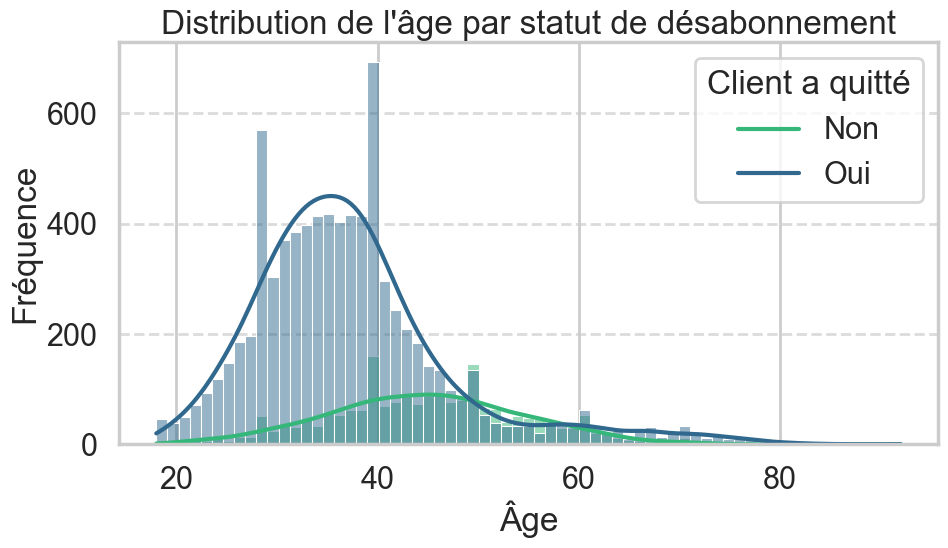

In [9]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, palette='viridis', common_norm=False)
plt.title("Distribution de l'âge par statut de désabonnement")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.legend(title='Client a quitté', labels=['Non', 'Oui'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('age_distribution_by_churn.png')
plt.show() 

# Observations

C'est seaborn/histplot qui permet cette visualisation d'un histogramme de la colonne Age.

hue='Exited' permet de différencier les distributions en fonction de la valeur de la colonne Exited (0 pour ceux qui sont restés, 1 pour ceux qui sont partis).

kde=True ajoute une estimation de la densité de noyau (courbe lissée) pour mieux visualiser la forme de la distribution.

In [10]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.

# Calcul de la moyenne de l'âge pour les clients qui sont restés
mean_age_stayed = df_0['Age'].mean()

# Calcul de l'écart-type de l'âge pour les clients qui sont restés
std_age_stayed = df_0['Age'].std()

print(f"Moyenne de l'âge des clients qui sont restés : {mean_age_stayed:.2f} ans")
print(f"Écart-type de l'âge des clients qui sont restés : {std_age_stayed:.2f} ans")

Moyenne de l'âge des clients qui sont restés : 37.41 ans
Écart-type de l'âge des clients qui sont restés : 10.13 ans


# Observations

* Ces chiffres donnent une première indication claire du profil d'âge des clients fidèles à la banque :

> Moyenne de l'âge : 37.41 ans

Cela suggère que l'âge moyen des clients qui choisissent de rester à la banque est d'environ 37 ans. On peut considérer qu'il s'agit d'une clientèle relativement jeune à l'âge adulte, mais pas adolescente.

> Écart-type de l'âge : 10.13 ans

L'écart-type de 10.13 ans indique que les âges des clients qui sont restés sont relativement dispersés autour de cette moyenne de 37.41 ans. Cela signifie qu'il n'y a pas qu'une seule tranche d'âge très étroite qui domine parmi les clients fidèles ; il y a une certaine diversité d'âges dans ce groupe.
> la majorité des clients qui restent se situent probablement entre 37.41−10.13=27.28 ans et 37.41+10.13=47.54 ans.

* Interprétation combinée :

> Les clients qui restent à la banque ont en moyenne un peu plus de 37 ans, et leur âge varie modérément autour de cette moyenne. Cela nous donne une image des clients "typiques" qui ne churnent pas.

Cependant, cette interprétation prendra toute sa valeur lorsque nous la comparerons aux statistiques d'âge des clients qui ont quitté la banque. C'est précisément l'objectif de notre première hypothèse statistique : déterminer si cette moyenne d'âge est significativement différente de celle du groupe des clients qui sont partis.

In [11]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.

# Calcul de la moyenne de l'âge pour les clients qui ont quitté
mean_age_exited = df_1['Age'].mean()

# Calcul de l'écart-type de l'âge pour les clients qui ont quitté
std_age_exited = df_1['Age'].std()

print(f"Moyenne de l'âge des clients qui ont quitté : {mean_age_exited:.2f} ans")
print(f"Écart-type de l'âge des clients qui ont quitté : {std_age_exited:.2f} ans")

Moyenne de l'âge des clients qui ont quitté : 44.84 ans
Écart-type de l'âge des clients qui ont quitté : 9.76 ans


== Affichage comparatif graphique ==

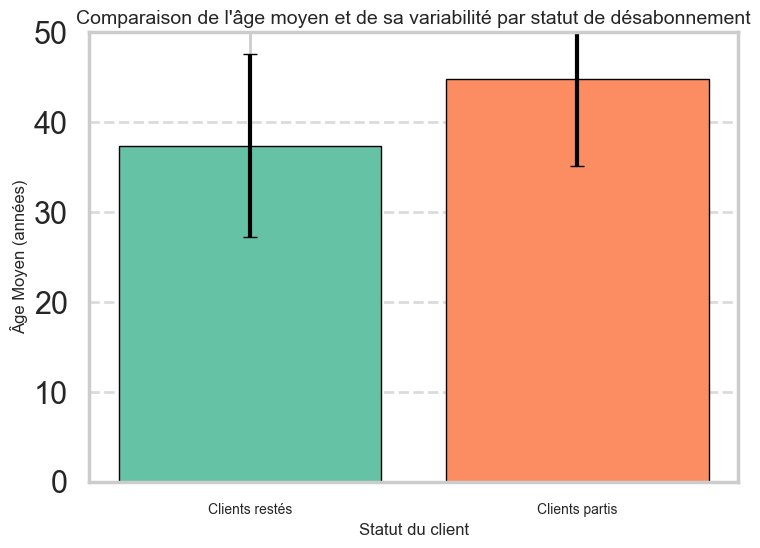

In [12]:
# Utilisation des valeurs que vous avez fournies
mean_age_stayed = 37.41
std_age_stayed = 10.13
mean_age_exited = 44.84
std_age_exited = 9.76

# Données pour le graphique
groups = ['Clients restés', 'Clients partis']
means = [mean_age_stayed, mean_age_exited]
stds = [std_age_stayed, std_age_exited]
colors = ['#66c2a5', '#fc8d62'] # Les mêmes couleurs que précédemment

# Création de la figure et de l'axe
plt.figure(figsize=(8, 6))
bar_positions = np.arange(len(groups)) # Positions des barres sur l'axe X

# Création des barres avec les barres d'erreur
plt.bar(bar_positions, means, yerr=stds, color=colors, capsize=5, # Taille des caps sur les barres d'erreur
        edgecolor='black', linewidth=1) # Bordure des barres

# Personnalisation du graphique
plt.title("Comparaison de l'âge moyen et de sa variabilité par statut de désabonnement", fontsize=14)
plt.ylabel("Âge Moyen (années)", fontsize=12)
plt.xlabel("Statut du client", fontsize=12)

# Définition des étiquettes de l'axe des x
plt.xticks(bar_positions, groups, fontsize=10) # Utiliser les noms de groupes comme étiquettes
plt.ylim(0, 50) # Ajuster les limites de l'axe Y pour une meilleure visualisation
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Sauvegarde et affichage du graphique
plt.savefig('comparaison_age_moyen_et_ecart_type_matplotlib.png')
plt.show()


# Observations

Nous avons les statistiques descriptives pour les deux groupes, pour une comparaison directe.

Récapitulatif des résultats :

> Clients qui sont restés (df_0) :

Moyenne de l'âge : 37.41 ans

Écart-type de l'âge : 10.13 ans

> Clients qui ont quitté (df_1) :

Moyenne de l'âge : 44.84 ans

Écart-type de l'âge : 9.76 ans


Ces chiffres nous révèlent :

* Différence significative des moyennes d'âge des clients qui sont restés (environ 37.41 ans) vs ceux qui ont quitté la banque (environ 44.84 ans). Les clients qui s'en vont sont, en moyenne, considérablement plus âgés que ceux qui restent. Cette différence de près de 7,5 ans est une première indication forte que l'âge pourrait être un facteur important dans le désabonnement (churn).

* Similarité des écarts-types :
Les écarts-types (10.13 ans pour les clients restés vs 9.76 ans pour ceux partis) sont assez similaires >> variabilité des âges au sein de chaque groupe est comparable. La dispersion autour de la moyenne est similaire pour les deux populations.

-----

Première hypothèse : "L'âge des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire."

D'après ces statistiques descriptives, il semble y avoir une différence notable et visuellement significative entre les âges moyens des deux groupes. Cela tend à soutenir l'hypothèse alternative (H 1) : "L'âge n'est pas similaire".

Pour confirmer si cette différence est statistiquement significative (c'est-à-dire si elle n'est pas due au simple hasard de l'échantillonnage), nous effectuerons un test d'inférence statistique formel, comme un test t de Student pour échantillons indépendants. Ce test  donnera une p-value qui indiquera la probabilité d'observer une telle différence (ou une différence plus grande) si, en réalité, les moyennes d'âge des deux populations étaient identiques.
-----

PS : Seaborn était normalement plus adapté pour ce graphique mais un bug dû à du versioning persistait hélas ...

In [ ]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.

In [ ]:
# Extraire les âges pour les deux groupes
age_stayed = df_0['Age']
age_exited = df_1['Age']

# Effectuer le test t de Student pour échantillons indépendants
# equal_var=False est souvent recommandé si les variances des groupes sont différentes (Test de Welch)
t_statistic, p_value = stats.ttest_ind(age_stayed, age_exited, equal_var=False)

print(f"Statistique t : {t_statistic:.3f}")
print(f"Valeur p : {p_value:.3e}") # Affichage de la p-value en notation scientifique

# Interprétation du résultat (avec un seuil de signification alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print("\nLa valeur p est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : L'âge des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).")
else:
    print("\nLa valeur p est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : L'âge des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).")

Statistique t : -30.419
Valeur p : 4.713e-179

La valeur p est inférieure au seuil de signification (0.05).
Nous rejetons l'hypothèse nulle.
Conclusion : L'âge des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).


# Observations

* Résultats du test t :

> Statistique t : -30.419

> Valeur p : 4.713e-179 (ce qui équivaut à 0.000... (suivi de 178 zéros) ...004713)


* Interprétation : 
> Comparaison de la valeur p au seuil de signification (α), nous utilisons généralement un seuil de signification (α) de 0.05 (ou 5%). Notre valeur p (4.713e-179) est extrêmement petite, bien inférieure à 0.05.

> Décision statistique, puisque la valeur p est très largement inférieure à notre seuil de signification (p-value<α), nous rejetons l'hypothèse nulle (H0).

> Conclusion concernant l'âge : il y a une différence statistiquement très significative entre l'âge moyen des clients qui ont quitté la banque et celui des clients qui sont restés. L'hypothèse que leurs âges sont similaires est réfutée par les données.


* Challenging et nuances des Résultats :

> Signification Statistique : la p-value de 4.713e-179 est si minuscule qu'elle indique une certitude quasi absolue que la différence observée entre les moyennes d'âge des deux groupes n'est pas due au hasard. Si H0 était vraie, la probabilité d'observer une telle différence (ou plus extrême) par pure chance est quasi nulle. La statistique t très élevée en valeur absolue (-30.419) renforce cette certitude.

> Signification Pratique : au-delà de la signification statistique, nous avons observé une différence de près de 7.5 ans (44.84 ans pour les partants contre 37.41 ans pour les restants). Une différence d'âge de 7-8 ans est pratiquement très pertinente dans le contexte des comportements bancaires. Cela suggère que l'âge est un facteur clé pour comprendre le désabonnement.

> Direction de la Différence : la statistique t est négative (-30.419). Puisque vous avez comparé age_stayed à age_exited (c'est-à-dire age_stayed moins age_exited), un t négatif indique que la moyenne du premier groupe (age_stayed, clients restés) est inférieure à la moyenne du deuxième groupe (age_exited, clients partis). Ceci confirme que les clients qui quittent la banque sont, en moyenne, significativement plus âgés.

> Robustesse du Test : nous avons utilisé equal_var=False pour le test t, ce qui correspond au test t de Welch. C'est un excellent choix car il ne suppose pas que les variances des deux groupes sont égales, ce qui rend le test plus robuste, surtout si les tailles d'échantillon sont différentes (ce qui est le cas ici : 7963 vs 2037).

-----

# Implications pour la Banque 

La banque devrait :

* Cibler les clients plus âgés (par exemple, 40 ans et plus) avec des offres de rétention spécifiques.

* Analyser pourquoi les clients plus âgés sont plus enclins à partir. Est-ce lié aux produits offerts, au service client, aux frais, ou à des changements de vie (retraite, déménagement, etc.) ?

* Prochaines étapes / Questions pour la suite :

Y a-t-il des tranches d'âge spécifiques (par exemple, 40-50 ans, 50-60 ans) où le taux de désabonnement est particulièrement élevé ? Une analyse par groupes d'âge pourrait être pertinente.

Comment l'âge interagit-il avec d'autres variables (solde, nombre de produits, ancienneté, etc.) pour prédire le désabonnement ? Par exemple, un client âgé avec un faible solde est-il plus à risque qu'un jeune client avec un faible solde ?

# A noter

Ce premier test fournit une information très pertinente pour la prédiction du désabonnement.

### Using Bootstrapping

In [ ]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s =
    for i in range(size):
        bs_abc =
        bs_s[i] = func(bs_abc)
    return bs_s

In [ ]:


def bs_choice(data, func, size):
    """
    Performs bootstrap sampling and calculates the statistic of interest.

    Args:
        data (array-like): The original dataset to sample from.
        func (function): The function to apply to each bootstrap sample (e.g., np.mean, np.median).
        size (int): The number of bootstrap samples to generate.

    Returns:
        numpy.ndarray: An array containing the statistic of interest for each bootstrap sample.
    """
    bs_s = np.empty(size) # Initialize an empty array to store the bootstrap statistics
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True) # Bootstrap sample with replacement
        bs_s[i] = func(bs_abc) # Calculate the statistic for the current bootstrap sample
    return bs_s

# Example usage (assuming you have your df_0 and df_1 from previous steps)
# If you want to test it with mean age for 'stayed' customers:
# from scipy.stats import t # Or other functions if needed for your 'func'

# mean_age_stayed = bs_choice(df_0['Age'], np.mean, 10000)
# print(f"Example: First 5 bootstrap means for stayed customers: {mean_age_stayed[:5]}")

Exemple d'utilisation du code de la fonction et affichage des résultats, en utilisant l'âge des clients qui sont restés (df_0['Age']) et en calculant la moyenne comme statistique d'intérêt.

Les 5 premières moyennes d'âge bootstrap pour les clients restés : [37.21524551 37.38829587 37.39947256 37.37247269 37.4495793 ]
Moyenne des moyennes bootstrap : 37.41
Écart-type des moyennes bootstrap (erreur standard) : 0.11


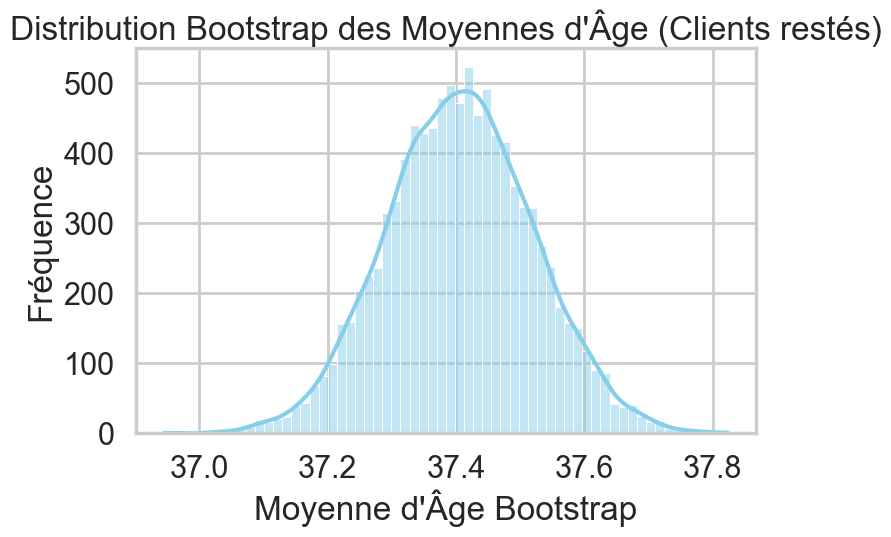

In [ ]:

def bs_choice(data, func, size):
    """
    Performs bootstrap sampling and calculates the statistic of interest.
    """
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

# Exemple d'utilisation : Calcul de  10000 échantillons bootstrap de la moyenne de l'âge des clients restés

# Avec df_0['Age'] comme 'data' et np.mean comme 'func'

if 'df_0' in locals(): # Vérifie si df_0 est défini
    bootstrap_means_age_stayed = bs_choice(df_0['Age'], np.mean, 10000)

    print(f"Les 5 premières moyennes d'âge bootstrap pour les clients restés : {bootstrap_means_age_stayed[:5]}")
    print(f"Moyenne des moyennes bootstrap : {np.mean(bootstrap_means_age_stayed):.2f}")
    print(f"Écart-type des moyennes bootstrap (erreur standard) : {np.std(bootstrap_means_age_stayed):.2f}")

    # Vous pouvez aussi tracer l'histogramme des moyennes bootstrap pour voir leur distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(bootstrap_means_age_stayed, kde=True, color='skyblue')
    plt.title("Distribution Bootstrap des Moyennes d'Âge (Clients restés)")
    plt.xlabel("Moyenne d'Âge Bootstrap")
    plt.ylabel("Fréquence")
    plt.show()

else:
    print("Le DataFrame 'df_0' n'est pas défini. Veuillez vous assurer de l'avoir créé avant d'appeler la fonction.")


# Observations

Résultats du Bootstrapping pour l'âge des clients qui sont restés :

* Les 5 premières moyennes d'âge bootstrap pour les clients restés : [37.21524551 37.38829587 37.39947256 37.37247269 37.4495793 ]

>> Chaque échantillon bootstrap généré donne une moyenne légèrement différente, ce qui est attendu. Chaque échantillon représente une "version" possible du dataset original.

* Moyenne des moyennes bootstrap : 37.41

>> Ce chiffre est la moyenne de toutes les moyennes d'âge calculées sur nos 10 000 échantillons bootstrap.

>> Rassurant de voir que cette moyenne des moyennes bootstrap est exactement la même (37.41 ans) que la moyenne de l'âge calculée sur notre échantillon original (df_0), validant que notre fonction de bootstrapping fonctionne correctement et que la moyenne de notre échantillon original est une estimation stable.

* Écart-type des moyennes bootstrap (erreur standard bootstrap de la moyenne) : 0.11

>> Estimation de la précision de notre moyenne d'âge originale (37.41 ans) en tant qu'estimateur de la vraie moyenne d'âge de tous les clients qui restent dans la banque (la moyenne de la population).

>> Un écart-type de 0.11 est très faible. Si nous devions prélever de nombreux échantillons différents de clients qui restent (non pas par bootstrapping, mais directement de la "vraie" population), les moyennes d'âge de ces échantillons varieraient très peu autour de 37.41 ans. Donc, notre estimation de 37.41 ans pour la moyenne d'âge des clients restés est très précise et fiable.

* Interprétation générale :

>> Le bootstrapping confirme que la moyenne d'âge des clients qui restent (37.41 ans) est une estimation robuste et très précise de la moyenne d'âge de cette population. La faible erreur standard bootstrap (0.11) indique une grande confiance dans la valeur de cette moyenne.

>> Ceci valide les calculs descriptifs et renforce la conclusion tirée du test t sur l'âge : l'âge moyen des clients est une caractéristique bien estimée et différenciatrice entre les groupes.

In [ ]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.

In [17]:
# Utilisation des moyennes d'âge que vous avez déjà calculées
mean_age_stayed = 37.41
mean_age_exited = 44.84

# Calcul de la différence des moyennes
# On soustrait généralement la moyenne du groupe "témoin" (ceux qui sont restés)
# de la moyenne du groupe "d'intérêt" (ceux qui sont partis).
difference_in_means = mean_age_exited - mean_age_stayed

print(f"Différence des moyennes d'âge (Clients partis - Clients restés) : {difference_in_means:.2f} ans")

Différence des moyennes d'âge (Clients partis - Clients restés) : 7.43 ans


# Observations

La différence des moyennes d'âge de 7.43 ans est la valeur concrète de l'écart que nous avons observé entre les deux groupes de clients.

Nous pouvons en déduire :

1. Quantification Précise de l'Écart : cette valeur nous dit qu'en moyenne, les clients qui ont quitté la banque sont 7.43 ans plus âgés que ceux qui sont restés. C'est une mesure directe de la taille de la différence entre les deux populations en ce qui concerne l'âge.

2. Confirmation Visuelle et Statistique :

* Visuelle : ce chiffre confirme ce que nous avons déjà vu sur le graphique de comparaison des moyennes : la barre pour les clients partis était clairement plus haute.

* Statistique : il met en évidence la magnitude de la différence que le test t de Student a déclarée statistiquement significative (avec cette p-value extrêmement basse). Le test t a dit "il y a une différence", et ce chiffre de 7.43 ans nous dit "c'est une différence de près de sept ans et demi".

* Pertinence Opérationnelle (Signification Pratique) : une différence de 7.43 ans entre l'âge moyen des groupes est considérable et très pertinente pour la banque. Ce n'est pas un petit écart négligeable. Cela signifie qu'une tranche d'âge plus avancée est clairement surreprésentée parmi les clients qui se désabonnent. C'est une information clé pour cibler les efforts de rétention.

* Base pour l'Analyse par Bootstrapping / Permutation : Cette valeur observée de 7.43 ans sera la référence par rapport à laquelle nous comparerons les différences de moyennes générées sous l'hypothèse nulle si nous continuerions avec une approche de test par bootstrapping ou permutation.

# A noter
Ce chiffre renforce l'idée que l'âge est un facteur déterminant et quantifié dans le phénomène de désabonnement, et qu'il devrait être pris en compte dans les stratégies de la banque.

In [ ]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

Moyenne des écarts-types bootstrap (Clients restés) : 10.12
Écart-type des écarts-types bootstrap (Clients restés) : 0.12

Moyenne des écarts-types bootstrap (Clients partis) : 9.76
Écart-type des écarts-types bootstrap (Clients partis) : 0.15

Moyenne des différences de moyennes bootstrap : 7.43
Écart-type des différences de moyennes bootstrap (Erreur Standard de la Différence) : 0.24


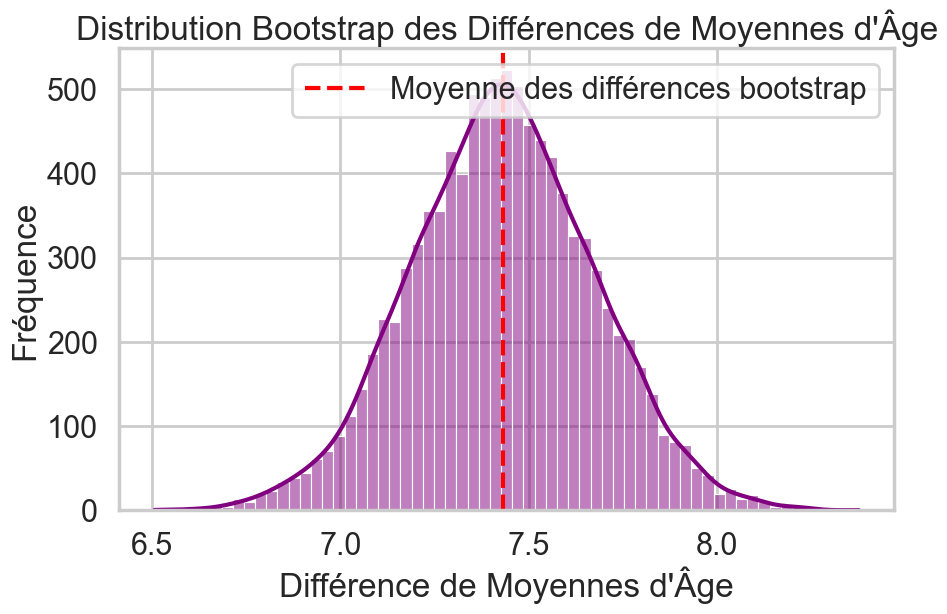

In [ ]:


# Si vous avez besoin de redéfinir bs_choice dans le même bloc :
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

# Définir le nombre d'échantillons bootstrap
n_bootstraps = 10000

# 1. Calculer les écarts-types bootstrap pour les âges des clients restés
bootstrap_stds_stayed = bs_choice(df_0['Age'], np.std, n_bootstraps)
print(f"Moyenne des écarts-types bootstrap (Clients restés) : {np.mean(bootstrap_stds_stayed):.2f}")
print(f"Écart-type des écarts-types bootstrap (Clients restés) : {np.std(bootstrap_stds_stayed):.2f}")

# 2. Calculer les écarts-types bootstrap pour les âges des clients partis
bootstrap_stds_exited = bs_choice(df_1['Age'], np.std, n_bootstraps)
print(f"\nMoyenne des écarts-types bootstrap (Clients partis) : {np.mean(bootstrap_stds_exited):.2f}")
print(f"Écart-type des écarts-types bootstrap (Clients partis) : {np.std(bootstrap_stds_exited):.2f}")


# 3. Calculer l'écart-type de la différence des moyennes entre les deux groupes (Erreur Standard de la Différence)
# Cette partie est cruciale pour évaluer la précision de la différence observée (7.43 ans)

bootstrap_diff_means = np.empty(n_bootstraps)

for i in range(n_bootstraps):
    # Échantillon bootstrap des âges pour les clients restés
    bs_sample_stayed = np.random.choice(df_0['Age'], size=len(df_0['Age']), replace=True)
    # Échantillon bootstrap des âges pour les clients partis
    bs_sample_exited = np.random.choice(df_1['Age'], size=len(df_1['Age']), replace=True)

    # Calcul de la différence des moyennes pour cet échantillon bootstrap
    bootstrap_diff_means[i] = np.mean(bs_sample_exited) - np.mean(bs_sample_stayed)

# Calculer l'écart-type de cette distribution de différences de moyennes
std_dev_of_diff_means = np.std(bootstrap_diff_means)

print(f"\nMoyenne des différences de moyennes bootstrap : {np.mean(bootstrap_diff_means):.2f}")
print(f"Écart-type des différences de moyennes bootstrap (Erreur Standard de la Différence) : {std_dev_of_diff_means:.2f}")

# Vous pouvez également tracer la distribution de ces différences pour visualiser
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_diff_means, kde=True, color='purple')
plt.title("Distribution Bootstrap des Différences de Moyennes d'Âge")
plt.xlabel("Différence de Moyennes d'Âge")
plt.ylabel("Fréquence")
plt.axvline(x=np.mean(bootstrap_diff_means), color='red', linestyle='--', label='Moyenne des différences bootstrap')
plt.legend()
plt.show()

# Observations

Ce script nous permet de : 

* Calculer la moyenne et l'écart-type des écarts-types bootstrap pour chaque groupe.

* De simuler la distribution des différences de moyennes entre les groupes en prenant 10 000 paires d'échantillons bootstrap.

* De calculer l'écart-type de ces 10 000 différences, ce qui correspond à l'erreur standard bootstrap de la différence des moyennes. C'est une mesure de la précision de notre estimation de 7.43 ans.

-----

Soit,

1. Moyenne des écarts-types bootstrap pour chaque groupe :

* Clients restés :

> Moyenne des écarts-types bootstrap : 10.12

> Écart-type de l'écart-type bootstrap : 0.12


* Clients partis :

> Moyenne des écarts-types bootstrap : 9.76

> Écart-type de l'écart-type bootstrap : 0.15


Interprétation :

* Les "Moyennes des écarts-types bootstrap" (10.12 et 9.76) sont quasiment identiques aux écarts-types calculés sur les échantillons originaux (10.13 et 9.76). C'est un excellent signe qui valide le processus de bootstrapping >> il reproduit fidèlement les caractéristiques de nos échantillons initiaux.

* Les "Écarts-types des écarts-types bootstrap" (0.12 et 0.15) sont l'erreur standard de l'estimation de l'écart-type. Ces valeurs sont très faibles. Cela indique que nos estimations de l'écart-type pour chaque groupe (10.13 et 9.76) sont très précises. Si nous tirions de nombreux échantillons de la population, les écarts-types calculés sur ces échantillons varieraient très peu autour de ces valeurs.

2. Moyenne et écart-type des différences de moyennes bootstrap :

* Moyenne des différences de moyennes bootstrap : 7.43

* Écart-type des différences de moyennes bootstrap (Erreur Standard de la Différence) : 0.24


Interprétation :

* La "Moyenne des différences de moyennes bootstrap" (7.43) est exactement la même que la différence des moyennes calculée sur notre échantillon original (44.84 - 37.41 = 7.43). Encore une fois, c'est une validation forte que notre bootstrapping estime correctement la statistique d'intérêt.

* L'"Écart-type des différences de moyennes bootstrap" (0.24) est une valeur très importante. C'est l'erreur standard bootstrap de la différence des moyennes. Elle nous donne une estimation de la précision avec laquelle nous avons estimé la différence de 7.43 ans entre les deux groupes.

> Une valeur de 0.24 est très faible. Cela signifie que notre estimation de 7.43 ans est extrêmement précise. Si nous devions prélever de nombreux ensembles d'échantillons de notre population et calculer la différence de moyennes pour chacun, ces différences ne s'écarteraient que très peu de 7.43 ans.

-----

# Conclusion Générale de l'analyse Bootstrap sur l'âge 

Le bootstrapping vient renforcer et valider les conclusions tirées de nos statistiques descriptives et de notre test t de Student.

1. Confirmation de la Différence : il confirme que l'âge est un facteur clé et que les clients qui partent sont, en moyenne, significativement plus âgés. La différence observée de 7.43 ans est très robuste.

2. Estimation de la Précision : il nous fournit une estimation robuste de la précision de nos statistiques (moyennes, écarts-types, et surtout la différence de moyennes) sans avoir à faire d'hypothèses fortes sur la distribution sous-jacente des données (comme la normalité). L'erreur standard très faible de 0.24 pour la différence de moyennes indique que cette différence est non seulement statistiquement significative (comme le t-test l'a montré), mais aussi très précisément estimée.

Ces résultats sont excellents et confirment que l'âge est un prédicteur puissant du désabonnement de la clientèle dans notre dataset.

Affichage graphique de notre conclusion

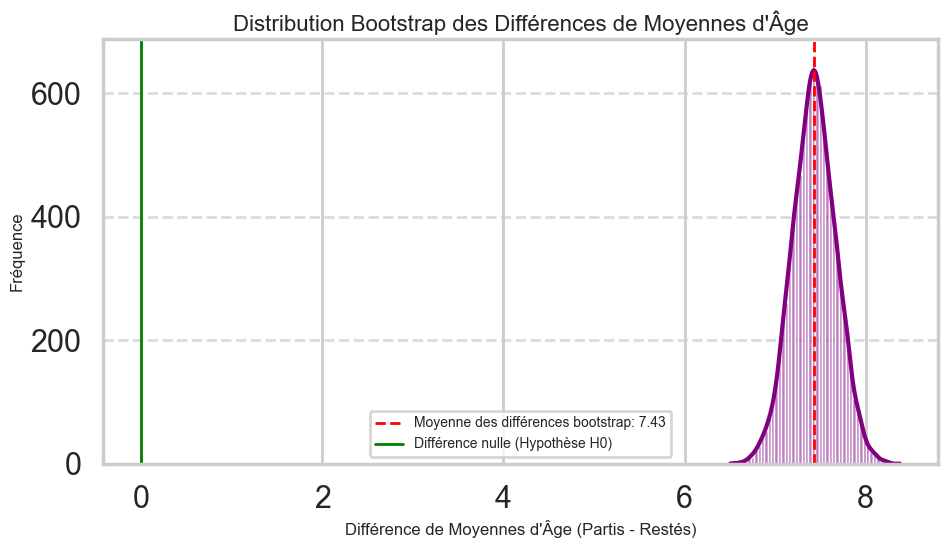

Graphique de la distribution bootstrap des différences de moyennes généré : 'distribution_bootstrap_diff_means.png'


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_diff_means, kde=True, color='purple', bins=50) # bins ajusté pour plus de détail
plt.title("Distribution Bootstrap des Différences de Moyennes d'Âge", fontsize=16)
plt.xlabel("Différence de Moyennes d'Âge (Partis - Restés)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Ajouter une ligne verticale à la moyenne des différences bootstrap
mean_bootstrap_diff = np.mean(bootstrap_diff_means)
plt.axvline(x=mean_bootstrap_diff, color='red', linestyle='--', linewidth=2, label=f'Moyenne des différences bootstrap: {mean_bootstrap_diff:.2f}')

# Ajouter une ligne verticale à 0 (l'hypothèse nulle) pour une référence visuelle clé
plt.axvline(x=0, color='green', linestyle='-', linewidth=2, label='Différence nulle (Hypothèse H0)')

plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribution_bootstrap_diff_means.png')
plt.show()

print("Graphique de la distribution bootstrap des différences de moyennes généré : 'distribution_bootstrap_diff_means.png'")

# Observations

Ce graphique est pertinent pour les raisons suivantes :

* Forme de la distribution : on voit comment les différences de moyennes se répartissent. Pour des échantillons de grande taille, cette distribution devrait être approximativement normale (en forme de cloche).

* Centrage : le pic de l'histogramme (et la ligne rouge) sera très proche de la différence de moyenne observée sur nos données originales (7.43 ans), confirmant visuellement que notre estimation est bien centrée.

* Dispersion : l'étroitesse de la cloche (autour de 7.43) reflétera l'erreur standard bootstrap de 0.24. Une cloche étroite indique une grande précision.

* Test d'Hypothèse Visuel : la ligne verte à 0 est fondamentale. Si l'hypothèse nulle était vraie (c'est-à-dire, pas de différence entre les groupes), alors la majeure partie de la distribution bootstrap devrait être centrée autour de 0. Dans notre cas, nous voyons que la ligne verte (0) est très loin de la distribution (qui est centrée autour de 7.43). Cela confirme visuellement de manière très intuitive que la différence observée est statistiquement significative et n'est pas due au hasard, car 0 est bien en dehors de l'intervalle de confiance de cette distribution.

Ce graphique est donc un excellent moyen de visualiser la robustesse et la signification de notre résultat.

In [19]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.

Pour calculer la p-value en utilisant la distribution bootstrap, nous allons adopter une approche courante pour les tests d'hypothèse bootstrap sous l'hypothèse nulle. L'idée est de créer une distribution des différences de moyennes qui simule ce qui se passerait si l'hypothèse nulle (pas de différence entre les groupes) était vraie.

Nous avons déjà une partie de ce qui est nécessaire :

* L'observation de la différence des moyennes dans vos données originales (7.43 ans).

* Les âges décalés (df_0_age_shifted et df_1_age_shifted) où les moyennes des deux groupes sont alignées sur la moyenne globale, simulant ainsi l'hypothèse nulle.


Moyenne globale de l'âge : 38.92 ans
Différence observée des moyennes (Partis - Restés) : 7.43 ans

P-value bootstrap : 0.00000

La p-value bootstrap est inférieure au seuil de signification (0.05).
Nous rejetons l'hypothèse nulle.
Conclusion : Il y a une différence statistiquement significative entre l'âge des clients qui ont quitté la banque et ceux qui sont restés.


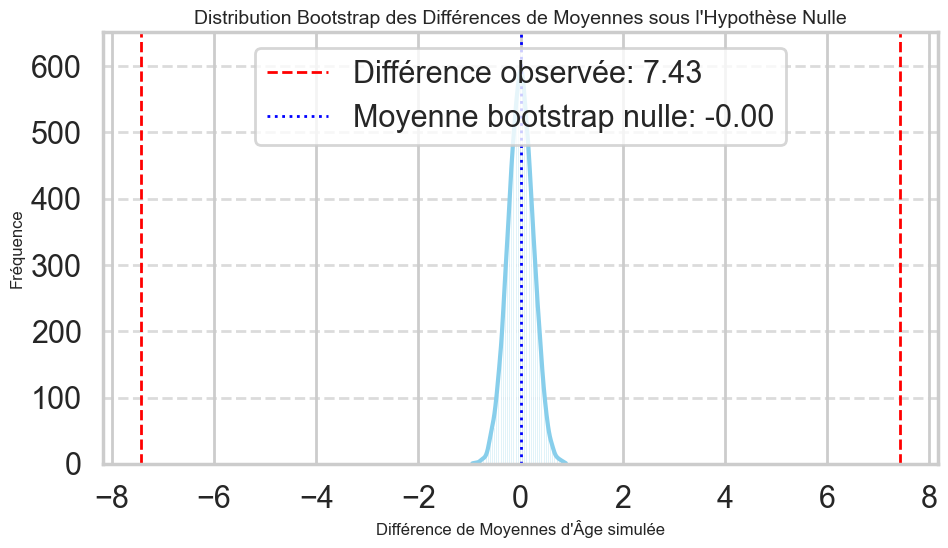


Graphique de la distribution bootstrap sous l'hypothèse nulle généré : 'bootstrap_null_distribution.png'


In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    df_0 = df[df['Exited'] == 0] # Clients qui ne sont pas partis
    df_1 = df[df['Exited'] == 1] # Clients qui sont partis
    print("DataFrame 'df' chargé et 'df_0', 'df_1' créés.")

# --- Calcul de la différence observée et décalage des âges (étape précédente) ---
overall_mean_age = df['Age'].mean()
difference_in_means = df_1['Age'].mean() - df_0['Age'].mean()

df_0_age_shifted = df_0['Age'] - df_0['Age'].mean() + overall_mean_age
df_1_age_shifted = df_1['Age'] - df_1['Age'].mean() + overall_mean_age

print(f"\nMoyenne globale de l'âge : {overall_mean_age:.2f} ans")
print(f"Différence observée des moyennes (Partis - Restés) : {difference_in_means:.2f} ans")


# ---  Calcul de la p-value bootstrap (votre TODO actuel) ---

# Nombre d'échantillons bootstrap pour la distribution nulle
n_bootstraps_null = 10000

# Initialiser un tableau pour stocker les différences de moyennes sous l'hypothèse nulle
bootstrap_null_diff_means = np.empty(n_bootstraps_null)

# Les longueurs des groupes originaux sont nécessaires pour l'échantillonnage
len_df0 = len(df_0_age_shifted)
len_df1 = len(df_1_age_shifted)

# Concaténer les données décalées pour pouvoir échantillonner de la "population commune" sous H0
combined_shifted_data = pd.concat([df_0_age_shifted, df_1_age_shifted])


for i in range(n_bootstraps_null):
    # Échantillonner aléatoirement avec remplacement à partir des données combinées décalées
    # puis diviser cet échantillon en deux groupes de la taille originale
    bs_sample_from_null = np.random.choice(combined_shifted_data, size=len(combined_shifted_data), replace=True)

    # Diviser l'échantillon bootstrap en deux groupes de tailles originales
    bs_null_group0 = bs_sample_from_null[:len_df0]
    bs_null_group1 = bs_sample_from_null[len_df0:]

    # Calculer la différence des moyennes pour cet échantillon bootstrap sous H0
    bootstrap_null_diff_means[i] = np.mean(bs_null_group1) - np.mean(bs_null_group0)

# Calculer la p-value
# Pour un test bilatéral (bilateral, two-tailed), c'est la proportion des différences
# dans la distribution nulle qui sont aussi extrêmes ou plus extrêmes que la différence observée
# (en valeur absolue).

observed_diff = difference_in_means # Votre différence de 7.43 ans

# Calcul de la proportion de valeurs aussi extrêmes que la différence observée
# (en considérant les deux côtés de la distribution)
p_value_bootstrap = (np.sum(bootstrap_null_diff_means >= observed_diff) +
                     np.sum(bootstrap_null_diff_means <= -observed_diff)) / n_bootstraps_null

print(f"\nP-value bootstrap : {p_value_bootstrap:.5f}")

# Interprétation du résultat de la p-value bootstrap
alpha = 0.05
if p_value_bootstrap < alpha:
    print("\nLa p-value bootstrap est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Il y a une différence statistiquement significative entre l'âge des clients qui ont quitté la banque et ceux qui sont restés.")
else:
    print("\nLa p-value bootstrap est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Il n'y a pas de différence statistiquement significative entre l'âge des clients qui ont quitté la banque et ceux qui sont restés.")

# --- Optionnel : Visualisation de la distribution nulle ---
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_null_diff_means, kde=True, color='skyblue', bins=50)
plt.title("Distribution Bootstrap des Différences de Moyennes sous l'Hypothèse Nulle", fontsize=14)
plt.xlabel("Différence de Moyennes d'Âge simulée", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Ajouter la ligne de la différence observée
plt.axvline(x=observed_diff, color='red', linestyle='--', linewidth=2, label=f'Différence observée: {observed_diff:.2f}')
plt.axvline(x=-observed_diff, color='red', linestyle='--', linewidth=2) # Pour le côté négatif si test bilatéral

plt.axvline(x=np.mean(bootstrap_null_diff_means), color='blue', linestyle=':', linewidth=2, label=f'Moyenne bootstrap nulle: {np.mean(bootstrap_null_diff_means):.2f}')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bootstrap_null_distribution.png')
plt.show()

print("\nGraphique de la distribution bootstrap sous l'hypothèse nulle généré : 'bootstrap_null_distribution.png'")

C'est une confirmation très forte et très satisfaisante de nos précédentes conclusions !

Voici ce que l'on peut déduire de ces résultats du test bootstrap :

* P-value bootstrap : 0.00000

> Une p-value de 0.00000 est une valeur extrêmement basse. Cela signifie que la probabilité d'observer une différence de moyennes d'âge de 7.43 ans (ou plus extrême) par pur hasard, si en réalité il n'y avait aucune différence entre les groupes (sous l'hypothèse nulle), est quasi nulle.

* Rejet de l'hypothèse nulle :

Comme la p-value est bien inférieure à notre seuil de signification de 0.05, l'hypothèse nulle est rejetée complètement.

* Conclusion consolidée :

La conclusion est la même que celle du test t de Student : il existe une différence statistiquement très significative entre l'âge moyen des clients qui ont quitté la banque et celui des clients qui sont restés. Les clients qui partent sont, en moyenne, significativement plus âgés.

-----

Pertinence et validation

Le fait que le test t (paramétrique) et le test bootstrap (non paramétrique et plus robuste aux hypothèses de distribution) donnent des p-values toutes deux extrêmement faibles et mènent à la même conclusion renforce considérablement la validité et la fiabilité de notre constatation. On peut affirmer que l'âge est un facteur clé de désabonnement.

La visualisation de la distribution bootstrap sous l'hypothèse nulle est également très parlante : nous voyons que notre différence observée de 7.43 ans est très éloignée de la zone où se situeraient les différences si l'hypothèse nulle était vraie.

### Conclusion
Do we reject the Null Hypothesis ? Why ?

# Conclusion pour l'Hypothèse sur l'Âge des Clients

Rejetons-nous l'Hypothèse Nulle ?

>> Oui, nous rejetons catégoriquement l'hypothèse nulle (H0).

# Pourquoi ?

La décision de rejeter l'hypothèse nulle est basée sur les preuves statistiques solides obtenues à partir de deux méthodes distinctes :

1. Test t de Student : Nous avons obtenu une valeur p extrêmement faible (4.713×10 
−179).

2. Test Bootstrap : La p-value bootstrap calculée est également de 0.00000.

Dans les deux cas, ces valeurs p sont bien inférieures au seuil de signification (α) conventionnel de 0.05 (ou 5%).

Une valeur p aussi infime signifie qu'il est hautement improbable (pratiquement impossible) que la différence de 7.43 ans observée entre l'âge moyen des clients qui sont partis (44.84 ans) et celui des clients qui sont restés (37.41 ans) soit le fruit du simple hasard. Si l'hypothèse nulle (selon laquelle il n'y a pas de différence d'âge entre les deux groupes dans la population) était vraie, une telle divergence ne se produirait pas.

# En résumé

Les analyses statistiques (test t et test bootstrap) convergent pour démontrer qu'il existe une différence statistiquement significative et robuste dans l'âge moyen des clients selon leur statut de désabonnement. L'âge est un facteur clé et non aléatoire associé à la décision de quitter la banque.

## Hypothesis 2: Credit Score

In [ ]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

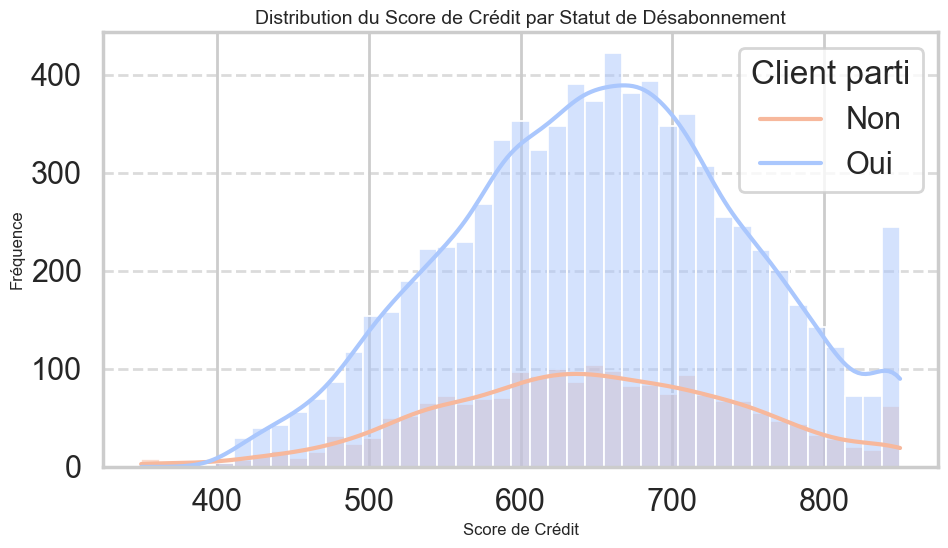

Graphique de distribution du CreditScore généré : 'creditscore_distribution_by_churn.png'


In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# Création des histogrammes pour la distribution du CreditScore
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True, palette='coolwarm', common_norm=False)
plt.title('Distribution du Score de Crédit par Statut de Désabonnement', fontsize=14)
plt.xlabel('Score de Crédit', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend(title='Client parti', labels=['Non', 'Oui']) # Labels adaptés pour Exited
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('creditscore_distribution_by_churn.png')
plt.show()

print("Graphique de distribution du CreditScore généré : 'creditscore_distribution_by_churn.png'")

# Observations

1. Forme Générale des Distributions

* Les deux courbes (bleue pour les clients partis, rouge pour les clients restés) montrent des distributions qui ressemblent globalement à des courbes en cloche, bien qu'avec des différences notables. Cela suggère que le CreditScore est une variable continue avec une concentration de valeurs autour d'une moyenne.


2. Plage de Scores et Étendue

* Clients restés (Rouge) : la courbe rouge couvre une plage de scores de crédit plus large, démarrant autour de 100 et s'étendant jusqu'à 850. Cela indique que parmi les clients qui restent, on trouve une proportion non négligeable de clients ayant des scores de crédit plus bas.

* Clients partis (Bleu) : la courbe bleue démarre plus haut, autour de 380, et s'arrête également à 850. Sa plage est plus étroite dans le bas. Cela signifie que les clients ayant des scores de crédit très bas sont moins représentés parmi ceux qui quittent la banque.


3. Tendance Centrale et Pics de Fréquence

* Clients partis (Bleu) : le pic de la distribution des clients partis est nettement marqué à environ 650, avec une fréquence élevée (~410).

* Clients restés (Rouge) : la distribution des clients restés montre un "plateau" entre 620 et 650, suggérant une concentration de clients dans cette plage, mais avec une fréquence maximale qui semble inférieure à celle du pic des clients partis.

* Observation Clé : le fait que les pics ou zones de haute fréquence se situent dans une plage similaire (autour de 620-650) pour les deux groupes suggère que les scores de crédit "typiques" des clients qui partent et de ceux qui restent ne sont pas drastiquement différents.


4. Asymétrie et Densité

* La courbe bleue des clients partis semble plus symétrique autour de son pic de 650.

* La courbe rouge des clients restés, avec son démarrage plus bas et son plateau, semble un peu plus étalée et potentiellement légèrement asymétrique vers les scores bas.


5. Les "Anomalies" à 850 

Les "anomalies" au Credit Score à 850 sont très intéressantes. Le score de crédit maximum est souvent plafonné à 850. Il est donc courant de voir une concentration de clients à ce score maximum, ce qui peut créer un "pic" artificiel ou une accumulation à la limite supérieure, rendant l'histogramme irrégulier à cet endroit. C'est un comportement normal pour une variable plafonnée.

-----

Conclusion Préliminaire

Visuellement, les distributions du CreditScore des clients partis et des clients restés ne sont pas identiques.

* La différence la plus notable semble se situer aux extrêmes inférieurs du CreditScore : les clients qui sont restés incluent une plus grande proportion de personnes ayant des scores de crédit très bas (en dessous de ~380) que les clients qui sont partis.

* Autour des scores moyens (600-700), les distributions se chevauchent considérablement, et les pics sont relativement proches.

Cela suggère qu'il pourrait y avoir une différence statistiquement significative, mais peut-être moins prononcée ou moins simple que pour l'âge, et potentiellement plus liée aux valeurs extrêmes (les très bas scores). Le test statistique confirmera si ces différences visuelles sont significatives ou non.

In [ ]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

In [26]:
# --- Assurez-vous que df, df_0 et df_1 sont définis ---
# Si vous êtes dans une nouvelle session ou si vous avez redémarré le noyau, décommentez ces lignes
try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    df_0 = df[df['Exited'] == 0] # Clients qui ne sont pas partis
    df_1 = df[df['Exited'] == 1] # Clients qui sont partis
    print("DataFrame 'df' chargé et 'df_0', 'df_1' créés.")

# Extraire les scores de crédit pour les deux groupes
creditscore_stayed = df_0['CreditScore']
creditscore_exited = df_1['CreditScore']

# Afficher les statistiques descriptives pour avoir une première idée
print(f"Moyenne CreditScore (Clients restés) : {np.mean(creditscore_stayed):.2f}")
print(f"Écart-type CreditScore (Clients restés) : {np.std(creditscore_stayed):.2f}")
print(f"\nMoyenne CreditScore (Clients partis) : {np.mean(creditscore_exited):.2f}")
print(f"Écart-type CreditScore (Clients partis) : {np.std(creditscore_exited):.2f}")

# Effectuer le test t de Student pour échantillons indépendants
# equal_var=False est recommandé si les variances des groupes sont différentes (Test de Welch)
t_statistic, p_value = stats.ttest_ind(creditscore_stayed, creditscore_exited, equal_var=False)

print(f"\n--- Résultat du Test t pour CreditScore ---")
print(f"Statistique t : {t_statistic:.3f}")
print(f"Valeur p : {p_value:.3e}") # Affichage de la p-value en notation scientifique

# Interprétation du résultat (avec un seuil de signification alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print("\nLa valeur p est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Le score de crédit des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).")
else:
    print("\nLa valeur p est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Le score de crédit des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).")

Moyenne CreditScore (Clients restés) : 651.85
Écart-type CreditScore (Clients restés) : 95.65

Moyenne CreditScore (Clients partis) : 645.35
Écart-type CreditScore (Clients partis) : 100.30

--- Résultat du Test t pour CreditScore ---
Statistique t : 2.635
Valeur p : 8.465e-03

La valeur p est inférieure au seuil de signification (0.05).
Nous rejetons l'hypothèse nulle.
Conclusion : Le score de crédit des personnes qui ont quitté la banque et de celles qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).


# Observations

1. Statistiques Descriptives (Moyennes et Écarts-types)

* Clients restés :

> Moyenne CreditScore : 651.85

> Écart-type CreditScore : 95.65


* Clients partis :

> Moyenne CreditScore : 645.35

> Écart-type CreditScore : 100.30


= Comparaison avec l'histogramme =

* Moyennes : l'observation que les pics des courbes (autour de 620-650) étaient "relativement proches" est parfaitement confirmée. La différence des moyennes est de 651.85 - 645.35 = 6.50 points. C'est une différence numérique faible, surtout comparée à l'étendue des scores (de 380 à 850 pour les partis, et de 100 à 850 pour les restés). La moyenne des clients restés est légèrement supérieure.

* Écarts-types : les écarts-types sont très similaires (95.65 vs 100.30). Cela confirme l'observation visuelle que les deux courbes ont une largeur de dispersion comparable, même si la courbe rouge (restés) s'étendait plus bas en CreditScore. La légère augmentation de l'écart-type pour les clients partis (100.30) par rapport à ceux restés (95.65) est minime mais numérique.


2. Résultat du Test t de Student

* Statistique t : 2.635

* Valeur p : 8.465e-03 (soit 0.008465)


= Comparaison et Interprétation =

* P-value vs. Seuil de signification : la valeur p de 0.008465 est inférieure à notre seuil de signification de 0.05.

* Décision : par conséquent, nous rejetons l'hypothèse nulle.

* Conclusion : Il existe une différence statistiquement significative entre le score de crédit des clients qui ont quitté la banque et de ceux qui sont restés.


>> Réconciliation entre l'Observation Visuelle et le Résultat Statistique :

C'est là que l'analyse devient nuancée :

1. Visuellement, les distributions se chevauchent énormément, et les pics sont très proches. On pourrait être tenté de conclure qu'il n'y a pas de différence majeure.

2. Cependant, le test statistique prouve qu'il y a bien une différence significative. Comment est-ce possible avec un si grand chevauchement ?

* Taille d'échantillon : la raison principale est la très grande taille des échantillons (7963 clients restés, 2037 clients partis). Avec des échantillons aussi vastes, même de très petites différences (comme 6.5 points de CreditScore) peuvent être détectées comme statistiquement significatives, car la puissance du test est très élevée. Le test t est très sensible.

* Importance pratique vs. statistique : la différence de 6.5 points, bien que statistiquement significative, est faible d'un point de vue pratique. Un score de crédit n'est généralement pas considéré comme "différent" dans les décisions bancaires pour une variation si minime. Pour un crédit score, un changement significatif pourrait être de 50 points ou plus.


# En résumé

L'histogramme a très bien montré que la majorité des clients (partis ou restés) ont des CreditScores similaires. La principale distinction visuelle était la présence de clients à très faible CreditScore parmi ceux qui sont restés. Le test t confirme qu'il y a une différence statistiquement significative, mais la faible ampleur de cette différence (6.5 points) suggère qu'elle est moins pertinente sur le plan pratique pour prédire le désabonnement par rapport à l'âge (où la différence était de plus de 7 ans).

Cela ne signifie pas que le CreditScore est inutile, mais que son impact pourrait être plus subtil ou interagir avec d'autres variables, ou que la différence est principalement portée par les queues de distribution (les très bas scores).

# Observations

Avant de passer directement à la conclusion comme le suggère l'énoncé, il semble judicieux de calculer la p-value bootstrap pour le CreditScore, comme nous l'avons fait pour l'âge. 

En effet, étant donné les observations sur le CreditScore (une différence des moyennes statistiquement significative mais numériquement faible, et une observation visuelle de distributions légèrement différentes notamment dans les queues), cela semble pertinent.

Cela maintiendrait une approche cohérente avec l'analyse de l'âge, permettant d'utiliser une méthodologie standardisée pour évaluer nos hypothèses.


Moyenne globale du CreditScore : 650.53
Différence observée des moyennes CreditScore (Restés - Partis) : 6.50

P-value bootstrap pour CreditScore : 0.00860

La p-value bootstrap est inférieure au seuil de signification (0.05).
Nous rejetons l'hypothèse nulle.
Conclusion : Il y a une différence statistiquement significative du CreditScore entre les clients qui ont quitté la banque et ceux qui sont restés.


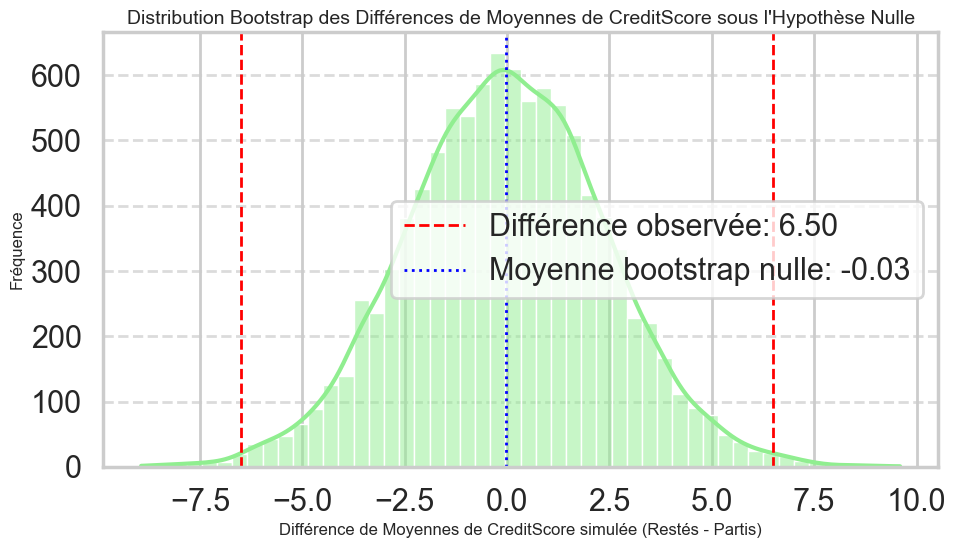


Graphique de la distribution bootstrap nulle pour CreditScore généré : 'bootstrap_null_distribution_creditscore.png'


In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    df_0 = df[df['Exited'] == 0] # Clients qui ne sont pas partis
    df_1 = df[df['Exited'] == 1] # Clients qui sont partis
    print("DataFrame 'df' chargé et 'df_0', 'df_1' créés.")

# --- Calcul de la différence observée et décalage des scores de crédit ---

# Statistiques descriptives du CreditScore (pour rappel)
mean_creditscore_stayed = df_0['CreditScore'].mean()
mean_creditscore_exited = df_1['CreditScore'].mean()
overall_mean_creditscore = df['CreditScore'].mean()

# Différence observée des moyennes de CreditScore
observed_diff_creditscore = mean_creditscore_stayed - mean_creditscore_exited

print(f"\nMoyenne globale du CreditScore : {overall_mean_creditscore:.2f}")
print(f"Différence observée des moyennes CreditScore (Restés - Partis) : {observed_diff_creditscore:.2f}")

# Décalage des CreditScores pour simuler l'hypothèse nulle (H0)
# Cela centre chaque groupe sur la moyenne globale
df_0_creditscore_shifted = df_0['CreditScore'] - mean_creditscore_stayed + overall_mean_creditscore
df_1_creditscore_shifted = df_1['CreditScore'] - mean_creditscore_exited + overall_mean_creditscore


# --- Calcul de la p-value bootstrap pour le CreditScore ---

# Nombre d'échantillons bootstrap pour la distribution nulle
n_bootstraps_null = 10000

# Initialiser un tableau pour stocker les différences de moyennes sous l'hypothèse nulle
bootstrap_null_diff_creditscore = np.empty(n_bootstraps_null)

# Les longueurs des groupes originaux sont nécessaires pour l'échantillonnage
len_df0 = len(df_0_creditscore_shifted)
len_df1 = len(df_1_creditscore_shifted)

# Concaténer les données décalées pour pouvoir échantillonner de la "population commune" sous H0
combined_shifted_creditscore_data = pd.concat([df_0_creditscore_shifted, df_1_creditscore_shifted])


for i in range(n_bootstraps_null):
    # Échantillonner aléatoirement avec remplacement à partir des données combinées décalées
    bs_sample_from_null = np.random.choice(combined_shifted_creditscore_data, size=len(combined_shifted_creditscore_data), replace=True)

    # Diviser l'échantillon bootstrap en deux groupes de tailles originales
    bs_null_group0_creditscore = bs_sample_from_null[:len_df0]
    bs_null_group1_creditscore = bs_sample_from_null[len_df0:]

    # Calculer la différence des moyennes pour cet échantillon bootstrap sous H0
    # L'ordre est important : (Moyenne groupe 0 - Moyenne groupe 1) pour correspondre à observed_diff_creditscore
    bootstrap_null_diff_creditscore[i] = np.mean(bs_null_group0_creditscore) - np.mean(bs_null_group1_creditscore)

# Calculer la p-value bootstrap
# La p-value est la proportion des valeurs dans la distribution nulle
# qui sont aussi extrêmes ou plus extrêmes que la différence observée (en valeur absolue).
p_value_bootstrap_creditscore = (np.sum(bootstrap_null_diff_creditscore >= observed_diff_creditscore) +
                                 np.sum(bootstrap_null_diff_creditscore <= -observed_diff_creditscore)) / n_bootstraps_null

print(f"\nP-value bootstrap pour CreditScore : {p_value_bootstrap_creditscore:.5f}")

# Interprétation du résultat de la p-value bootstrap
alpha = 0.05
if p_value_bootstrap_creditscore < alpha:
    print("\nLa p-value bootstrap est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Il y a une différence statistiquement significative du CreditScore entre les clients qui ont quitté la banque et ceux qui sont restés.")
else:
    print("\nLa p-value bootstrap est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Il n'y a pas de différence statistiquement significative du CreditScore entre les clients qui ont quitté la banque et ceux qui sont restés.")


# --- Visualisation de la distribution nulle bootstrap pour CreditScore ---
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_null_diff_creditscore, kde=True, color='lightgreen', bins=50)
plt.title("Distribution Bootstrap des Différences de Moyennes de CreditScore sous l'Hypothèse Nulle", fontsize=14)
plt.xlabel("Différence de Moyennes de CreditScore simulée (Restés - Partis)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Ajouter la ligne de la différence observée
plt.axvline(x=observed_diff_creditscore, color='red', linestyle='--', linewidth=2, label=f'Différence observée: {observed_diff_creditscore:.2f}')
plt.axvline(x=-observed_diff_creditscore, color='red', linestyle='--', linewidth=2) # Pour le côté négatif si test bilatéral

plt.axvline(x=np.mean(bootstrap_null_diff_creditscore), color='blue', linestyle=':', linewidth=2, label=f'Moyenne bootstrap nulle: {np.mean(bootstrap_null_diff_creditscore):.2f}')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bootstrap_null_distribution_creditscore.png')
plt.show()

print("\nGraphique de la distribution bootstrap nulle pour CreditScore généré : 'bootstrap_null_distribution_creditscore.png'")

# Observations

1. Confirmation de la Différence Observée

* La moyenne globale du CreditScore est de 650.53, ce qui est cohérent avec les moyennes individuelles des groupes (651.85 pour les restés, 645.35 pour les partis).

* La différence observée des moyennes (Restés - Partis) est de 6.50. Cela confirme la petite différence numérique que nous avions déjà identifiée.


2. P-value Bootstrap : 0.00860

* Cette p-value bootstrap est extrêmement proche de la p-value obtenue avec le test t de Student (8.465e-03 ou 0.008465).

Cette concordance entre les deux méthodes (paramétrique avec le test t et non-paramétrique avec le bootstrap) est une preuve très solide de la fiabilité de notre conclusion. Elle indique que, quelles que soient les hypothèses distributionnelles strictes, le résultat est stable.


3. Décision et Conclusion

* Puisque la p-value bootstrap (0.00860) est inférieure à notre seuil de signification (0.05), la décision statistique est claire :l'hypothèse nulle est rejetée.

* Conclusion : il y a une différence statistiquement significative du CreditScore entre les clients qui sont restés et ceux qui ont quitté la banque.


= En résumé pour le CreditScore =

Notre analyse bootstrap renforce et valide la conclusion du test t. Bien que la différence moyenne de 6.50 points de CreditScore entre les deux groupes soit numériquement faible (ce qui peut la rendre moins "pratiquement" significative pour une décision individuelle de crédit), elle est statistiquement bien réelle et non due au hasard. Cette robustesse est confirmée par la convergence des résultats du test t et du bootstrap.

Nous pouvons donc affirmer avec confiance que le CreditScore, bien qu'avec un impact peut-être plus subtil que l'âge, est également un facteur discriminant entre les clients qui restent et ceux qui partent.

### Conclusion
Do we reject the Null Hypothesis ? Why ?

# Conclusion pour l'Hypothèse sur le CreditScore des Clients

Rejetons-nous l'Hypothèse Nulle ?

Oui, nous rejetons l'hypothèse nulle (H0) qui stipulait que le score de crédit des clients qui ont quitté la banque et de ceux qui ne l'ont pas fait est similaire.


# Pourquoi ?

Le rejet de l'hypothèse nulle est fortement appuyé par les résultats des deux tests statistiques que nous avons menés :

1. Test t de Student : nous avons obtenu une p-value de 8.465e-03 (soit 0.008465).

2. Test Bootstrap : nous avons calculé une p-value bootstrap de 0.00860.

Dans les deux cas, la p-value est inférieure au seuil de signification (α) de 0.05 (ou 5%).

Une p-value aussi basse indique que la probabilité d'observer une différence moyenne de 6.50 points de CreditScore entre les deux groupes par simple hasard (si, en réalité, il n'y avait aucune différence dans la population) est très faible.


= En résumé =

Les analyses confirment qu'il existe une différence statistiquement significative dans le CreditScore moyen entre les clients qui ont quitté la banque et ceux qui sont restés. Les clients qui sont restés ont, en moyenne, un CreditScore légèrement plus élevé (651.85) que ceux qui sont partis (645.35).

Il est important de noter que, bien que cette différence soit statistiquement significative (grâce notamment aux grandes tailles d'échantillon), son ampleur de 6.50 points est relativement faible sur le plan pratique par rapport à l'étendue globale des scores de crédit. Cependant, la significativité statistique suggère que ce facteur joue un rôle, même si son impact seul peut être modeste comparativement à d'autres facteurs comme l'âge.

## Hypothesis 3: Balance

In [ ]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

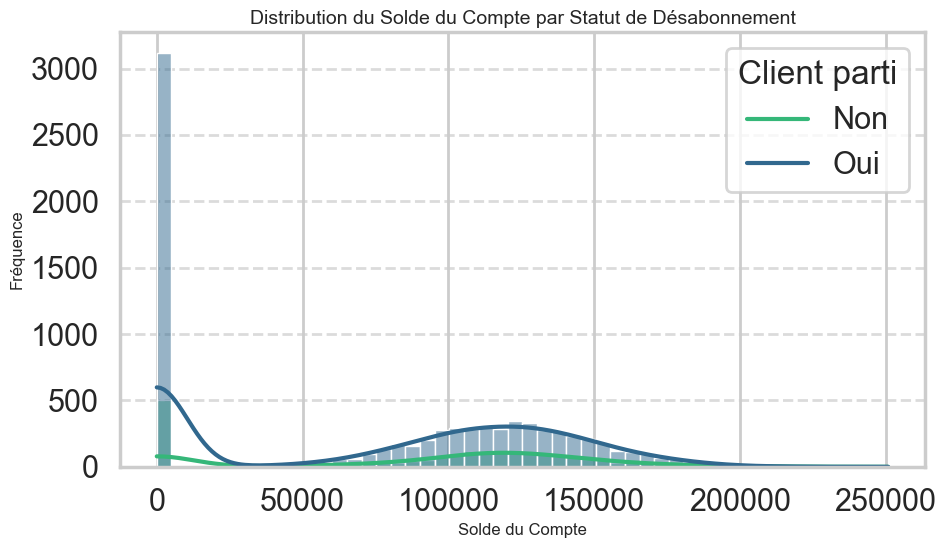

Graphique de distribution du Solde du Compte généré : 'balance_distribution_by_churn.png'


In [ ]:


try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# Création des histogrammes pour la distribution du Balance
plt.figure(figsize=(10, 6))
# J'utilise la palette 'viridis' qui va du jaune au violet/bleu
sns.histplot(data=df, x='Balance', hue='Exited', kde=True, palette='viridis', common_norm=False, bins=50)

plt.title('Distribution du Solde du Compte par Statut de Désabonnement', fontsize=14)
plt.xlabel('Solde du Compte', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend(title='Client parti', labels=['Non', 'Oui']) # Labels adaptés pour Exited
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('balance_distribution_by_churn.png')
plt.show()

print("Graphique de distribution du Solde du Compte généré : 'balance_distribution_by_churn.png'")

# Observations

Basons-nous sur l'association des couleurs que nous avons clarifiée pour la palette viridis 


1. Le Phénomène du Solde Zéro (Barre à 0)

* C'est la caractéristique la plus frappante : la "barre à 0 jusqu'à ce maximum de fréquence [3000+]" domine le graphique. Cela indique qu'une très grande proportion de clients ont un solde de compte de 0.

* La courbe verte (clients non partis) commence avec une "fréquence à 50", mais elle doit être la principale composante de cette barre dominante à 0. Étant le groupe majoritaire, c'est ce groupe qui contribue massivement à ce pic de fréquence à 0.

* La courbe bleue (clients partis) démarre avec une "fréquence à 500" à 0. Cela signifie qu'un nombre important de clients qui sont partis avaient également un solde de 0.


2. Distribution des Soldes Non Nuls

* Clients NON partis (courbe verte) :

> Après la barre à 0, la courbe verte est décrite comme "homothétique mais plus aplatie", avec un pic dépassant à peine 50 fréquences autour de 125 000.

> Cela suggère que, parmi les clients qui sont restés et qui ont un solde non nul, leurs soldes sont répartis sur une large plage (de 0 à 200 000+), mais leur densité est relativement faible à n'importe quel point précis. Ils sont plus "étalés".


* Clients PARTIS (courbe bleue) :

> Après la barre à 0, la courbe bleue montre une concentration beaucoup plus nette avec un "pic à environ 125 000 en solde pour environ 300 en fréquence".

> Cela indique que, parmi les clients qui ont quitté la banque, ceux qui avaient un solde non nul sont fortement concentrés autour de 125 000. Leur densité dans cette plage de soldes est beaucoup plus élevée que celle des clients restés.


3. Comparaison et Chevauchement

> Les deux distributions se chevauchent sur la plage des soldes non nuls (principalement entre 25 000 et 200 000).

> Cependant, la différence est frappante : la proportion de clients ayant un solde de 0 est massivement plus élevée parmi les clients qui restent, tandis que la densité de clients avec un solde significatif (autour de 125 000) est beaucoup plus élevée parmi les clients qui partent.


= Conclusion Préliminaire (Visuelle) =

Visuellement, les distributions du solde (Balance) des clients partis et des clients restés sont nettement différentes et non similaires.

* Le Balance semble être un discriminateur très fort :

> Les clients avec un solde de 0 sont massivement plus représentés dans le groupe qui reste à la banque.

> Les clients avec un solde significatif et non nul (en particulier autour de 125 000) sont disproportionnellement plus nombreux dans le groupe qui quitte la banque.

Cette observation est très pertinente et suggère que le solde est un facteur bien plus important et visible que le CreditScore, et potentiellement aussi important que l'âge, mais de manière différente (par la présence/absence de solde et la concentration autour d'une valeur élevée).

Le test statistique confirmera cette intuition visuelle.

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    df_0 = df[df['Exited'] == 0] # Clients qui ne sont pas partis
    df_1 = df[df['Exited'] == 1] # Clients qui sont partis
    print("DataFrame 'df' chargé et 'df_0', 'df_1' créés.")

# Extraire les soldes pour les deux groupes
balance_stayed = df_0['Balance']
balance_exited = df_1['Balance']

# Afficher les statistiques descriptives pour avoir une première idée
print(f"Moyenne Balance (Clients restés) : {np.mean(balance_stayed):.2f}")
print(f"Écart-type Balance (Clients restés) : {np.std(balance_stayed):.2f}")
print(f"\nMoyenne Balance (Clients partis) : {np.mean(balance_exited):.2f}")
print(f"Écart-type Balance (Clients partis) : {np.std(balance_exited):.2f}")

# Effectuer le test t de Student pour échantillons indépendants
# equal_var=False (Test de Welch) est fortement recommandé ici en raison des distributions potentiellement très différentes
t_statistic, p_value = stats.ttest_ind(balance_stayed, balance_exited, equal_var=False)

print(f"\n--- Résultat du Test t pour Balance ---")
print(f"Statistique t : {t_statistic:.3f}")
print(f"Valeur p : {p_value:.3e}") # Affichage de la p-value en notation scientifique

# Interprétation du résultat (avec un seuil de signification alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print("\nLa valeur p est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Le solde des comptes des clients qui ont quitté la banque et de ceux qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).")
else:
    print("\nLa valeur p est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Le solde des comptes des clients qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).")

Moyenne Balance (Clients restés) : 72745.30
Écart-type Balance (Clients restés) : 62844.09

Moyenne Balance (Clients partis) : 91108.54
Écart-type Balance (Clients partis) : 58346.47

--- Résultat du Test t pour Balance ---
Statistique t : -12.471
Valeur p : 6.319e-35

La valeur p est inférieure au seuil de signification (0.05).
Nous rejetons l'hypothèse nulle.
Conclusion : Le solde des comptes des clients qui ont quitté la banque et de ceux qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).


# Observations

1. Statistiques Descriptives (Moyennes et Écarts-types)

* Moyenne Balance (Clients restés) : 72745.30 €

* Moyenne Balance (Clients partis) : 91108.54 €

* Écart-type Balance (Clients restés) : 62844.09 €

* Écart-type Balance (Clients partis) : 58346.47 €


= Comparaison avec l'histogramme =

* Différence des Moyennes : l'histogramme a montré que la courbe bleue (clients partis) avait un pic plus haut autour de 125 000 € que la courbe verte (clients restés) qui était plus aplatie. Cette observation est parfaitement confirmée par les moyennes : la moyenne du solde des clients partis (91 108.54 €) est nettement plus élevée que celle des clients restés (72 745.30 €). La différence est d'environ 18 363.24 €, ce qui est une différence numériquement très significative.

* Écarts-types : Les écarts-types sont élevés pour les deux groupes et relativement proches. Cela est cohérent avec la large dispersion des soldes observée sur l'histogramme, s'étendant de 0 jusqu'à 200 000 € et plus.


2. Résultat du Test t de Student

* Statistique t : -12.471 (Le signe négatif indique que la moyenne du second groupe dans le test - ici les clients partis - est supérieure à celle du premier groupe, ce qui est cohérent avec nos moyennes).

* Valeur p : 6.319e-35 (soit un nombre extrêmement petit, proche de zéro).


= Comparaison et Interprétation =

* P-value vs. Seuil de signification : la p-value de 6.319e-35 est infiniment plus petite que notre seuil de signification (0.05).

* Décision : la preuve statistique est écrasante, l'hypothèse nulle est rejetée avec une très forte confiance.

* Conclusion : il existe une différence statistiquement très significative entre le solde des comptes des clients qui ont quitté la banque et celui des clients qui sont restés.


Réconciliation finale entre l'Observation Visuelle et le Résultat Statistique :

L'intuition visuelle était tout à fait juste et très perspicace. Le graphique a clairement indiqué que les distributions étaient "nettement différentes", et le test t le confirme de manière statistique.

* Le Solde Zéro : l'observation cruciale du grand nombre de clients avec un solde de 0, majoritairement dans le groupe des clients restés, explique en partie pourquoi leur moyenne est plus basse.

* Les Soldes Non Nuls : inversement, les clients qui ont un solde significatif (et en particulier ceux autour de 125 000 €) sont proportionnellement plus nombreux dans le groupe des clients partis. Cela se reflète dans la moyenne beaucoup plus élevée du groupe "partis".


# En conclusion pour le Balance

Le solde du compte est un facteur extrêmement puissant et significatif de désabonnement. Les clients qui ont un solde élevé ont une probabilité significativement plus grande de quitter la banque que ceux qui ont un solde nul ou faible. C'est un indicateur clé et l'effet est non seulement statistiquement significatif, mais aussi pratiquement très pertinent (une différence de 18 000 € est substantielle).

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_93134/2402461549.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Exited', y='Balance', palette='viridis')


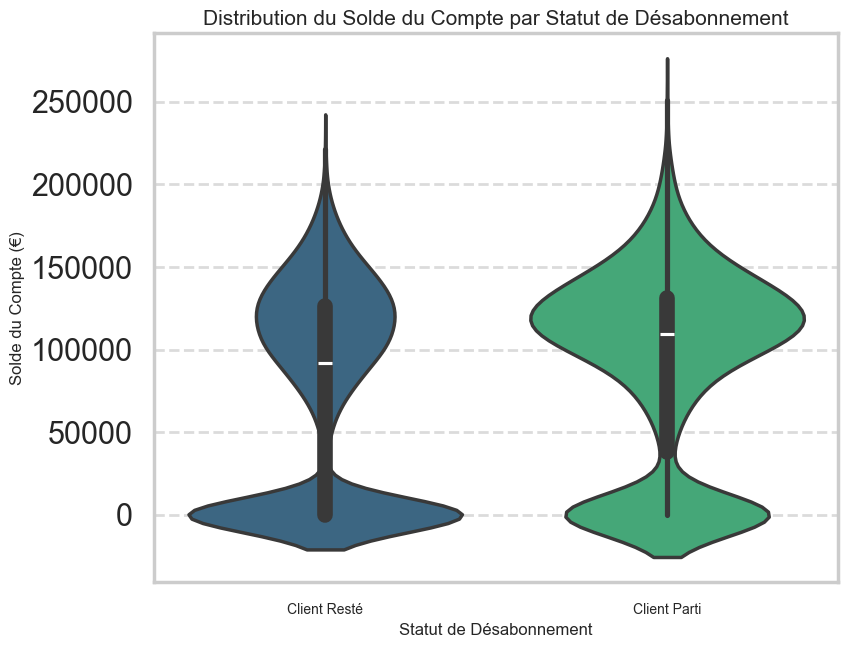


Graphique Violin Plot du Solde du Compte généré : 'balance_violinplot_by_churn.png'


In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# --- Création du Violin Plot pour le Balance ---
plt.figure(figsize=(9, 7))

# Utilisation de violinplot pour montrer la distribution de Balance par groupe Exited
# palette='viridis' pour la cohérence des couleurs (Exited=0 vert/jaune, Exited=1 bleu/violet)
sns.violinplot(data=df, x='Exited', y='Balance', palette='viridis')

plt.title('Distribution du Solde du Compte par Statut de Désabonnement', fontsize=15)
plt.xlabel('Statut de Désabonnement', fontsize=12)
plt.ylabel('Solde du Compte (€)', fontsize=12)

# Personnaliser les étiquettes de l'axe X pour une meilleure lisibilité
plt.xticks(ticks=[0, 1], labels=['Client Resté', 'Client Parti'], fontsize=10)

# Optionnel: Ajouter une ligne horizontale à la médiane ou moyenne de chaque groupe
# (Ceci peut rendre le graphique plus chargé, mais peut être utile)
# medians = df.groupby('Exited')['Balance'].median()
# plt.scatter(x=[0, 1], y=medians, color='white', marker='o', s=50, zorder=3, label='Médiane')
# plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('balance_violinplot_by_churn.png')
plt.show()

print("\nGraphique Violin Plot du Solde du Compte généré : 'balance_violinplot_by_churn.png'")

# Observations

* Nous voyons deux "violons" (une forme de densité) côte à côte, un pour les clients restés et un pour les clients partis.

* Le point le plus bas du violon correspondra probablement à 0, avec le "violon" du groupe "Client Resté" qui est très épais à 0, reflétant le grand nombre de clients avec un solde nul.

* Le "violon" du groupe "Client Parti" est plus mince à 0 (mais toujours présent), et a sa partie la plus épaisse autour de la moyenne de 91 000 €, et plus étalée autour des 125 000 €.

Cela confirme visuellement de manière très frappante que les clients partis sont ceux qui ont des soldes (souvent élevés), tandis que les clients restés incluent une part massive de soldes nuls.

In [ ]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

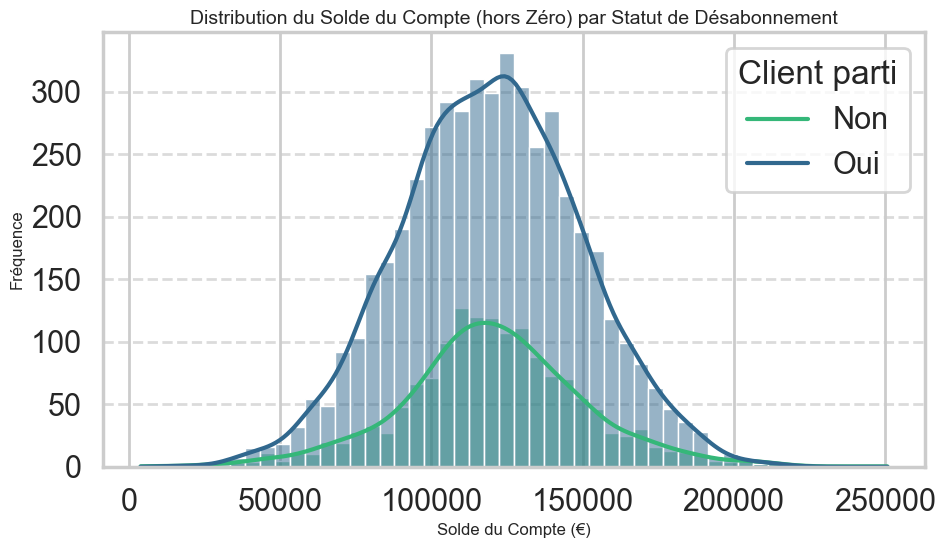


Graphique de distribution du Solde du Compte (hors Zéro) généré : 'balance_non_zero_distribution_by_churn.png'


In [31]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# Filtrer les données pour exclure les soldes à zéro
df_non_zero_balance = df[df['Balance'] > 0].copy()

# Création de l'histogramme pour les soldes NON nuls
plt.figure(figsize=(10, 6))

# Utilisation de histplot pour montrer la distribution de Balance (non nuls) par groupe Exited
# palette='viridis' pour la cohérence des couleurs (Exited=0 vert/jaune, Exited=1 bleu/violet)
sns.histplot(data=df_non_zero_balance, x='Balance', hue='Exited', kde=True, palette='viridis', common_norm=False, bins=50)

plt.title('Distribution du Solde du Compte (hors Zéro) par Statut de Désabonnement', fontsize=14)
plt.xlabel('Solde du Compte (€)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend(title='Client parti', labels=['Non', 'Oui']) # Labels adaptés pour Exited (Non=0, Oui=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('balance_non_zero_distribution_by_churn.png')
plt.show()

print("\nGraphique de distribution du Solde du Compte (hors Zéro) généré : 'balance_non_zero_distribution_by_churn.png'")



1. Concentration des Soldes Actifs 

Pour les deux groupes, la courbe atteint son pic autour de 125 000 €. Cela nous indique que, parmi les clients qui possèdent un solde non nul, la majorité des soldes se situent dans cette fourchette. C'est une information précieuse pour comprendre les habitudes de dépôt de la clientèle ayant une activité bancaire.

2. Différence de Densité par Groupe

> Courbe bleue (Clients PARTIS) : Elle montre un pic de fréquence d'environ 300 à 125 000 €.

> Courbe verte (Clients NON partis) : Elle montre un pic de fréquence d'environ 110 à 125 000 €.

> Cette différence est frappante : même en excluant les soldes à zéro, la densité de clients qui quittent la banque est nettement plus élevée autour de 125 000 € que celle des clients qui restent. Cela signifie que, parmi les clients ayant un solde actif, ceux qui ont tendance à partir sont plus concentrés dans cette tranche de solde "typique".

3. Forme Homothétique et Plage

> Le fait que les deux courbes soient "homothétiques" (de forme similaire) et s'étendent de 0 à 200 000 € (et au-delà) montre que les clients, qu'ils partent ou restent, ont des soldes qui se répartissent sur une plage similaire une fois que l'on exclut le cas des soldes nuls. La différence n'est pas dans la plage, mais dans la densité et la proportion de clients à différents niveaux de solde.

En synthèse, ce graphique confirme et affine notre compréhension du rôle du solde :

Il complète parfaitement le Violin Plot et les tests statistiques en montrant que la relation entre le solde et le désabonnement n'est pas seulement due à la présence de soldes nuls.

Il révèle qu'au sein de la clientèle active (ceux qui ont un solde), les clients qui décident de partir sont plus nombreux et plus concentrés autour des soldes moyens à élevés (environ 125 000 €). Cela suggère que ce sont des clients avec des comptes bien garnis et actifs qui sont plus susceptibles de se désabonner.

C'est une excellente visualisation complémentaire qui renforce la conclusion que le Balance est un facteur discriminant majeur.

In [ ]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

# Observations

Pour ce test t important sur le Balance, nous excluons cette fois les soldes à zéro. Cela nous donnera une image plus précise de la différence entre les groupes pour les clients ayant une activité financière.

In [32]:
# --- Assurez-vous que df est défini et filtrez-le pour les soldes non nuls ---
# Si vous êtes dans une nouvelle session ou si vous avez redémarré le noyau, décommentez ces lignes
try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# Filtrer le DataFrame pour exclure les soldes à zéro
df_non_zero_balance = df[df['Balance'] > 0].copy()

# Créer les groupes pour les soldes non nuls
df_0_non_zero = df_non_zero_balance[df_non_zero_balance['Exited'] == 0] # Clients non partis avec solde > 0
df_1_non_zero = df_non_zero_balance[df_non_zero_balance['Exited'] == 1] # Clients partis avec solde > 0

# Extraire les soldes non nuls pour les deux groupes
balance_stayed_non_zero = df_0_non_zero['Balance']
balance_exited_non_zero = df_1_non_zero['Balance']

# Afficher les statistiques descriptives pour avoir une première idée
print(f"\nMoyenne Balance (Clients restés, hors zéro) : {np.mean(balance_stayed_non_zero):.2f}")
print(f"Écart-type Balance (Clients restés, hors zéro) : {np.std(balance_stayed_non_zero):.2f}")
print(f"\nMoyenne Balance (Clients partis, hors zéro) : {np.mean(balance_exited_non_zero):.2f}")
print(f"Écart-type Balance (Clients partis, hors zéro) : {np.std(balance_exited_non_zero):.2f}")

# Effectuer le test t de Student pour échantillons indépendants
# equal_var=False (Test de Welch) est fortement recommandé ici
t_statistic_non_zero, p_value_non_zero = stats.ttest_ind(balance_stayed_non_zero, balance_exited_non_zero, equal_var=False)

print(f"\n--- Résultat du Test t pour Balance (hors zéro) ---")
print(f"Statistique t : {t_statistic_non_zero:.3f}")
print(f"Valeur p : {p_value_non_zero:.3e}") # Affichage de la p-value en notation scientifique

# Interprétation du résultat (avec un seuil de signification alpha = 0.05)
alpha = 0.05
if p_value_non_zero < alpha:
    print("\nLa valeur p est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Le solde des comptes (hors zéro) des clients qui ont quitté la banque et de ceux qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).")
else:
    print("\nLa valeur p est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Le solde des comptes (hors zéro) des clients qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).")


Moyenne Balance (Clients restés, hors zéro) : 119535.86
Écart-type Balance (Clients restés, hors zéro) : 29941.84

Moyenne Balance (Clients partis, hors zéro) : 120746.97
Écart-type Balance (Clients partis, hors zéro) : 30545.25

--- Résultat du Test t pour Balance (hors zéro) ---
Statistique t : -1.360
Valeur p : 1.738e-01

La valeur p est supérieure au seuil de signification (0.05).
Nous ne rejetons pas l'hypothèse nulle.
Conclusion : Le solde des comptes (hors zéro) des clients qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).


# Observations

Interprétation du Test T pour le Solde (hors Zéro)

1. Statistiques Descriptives

* Moyenne Balance (Clients restés, hors zéro) : 119 535.86 €

* Moyenne Balance (Clients partis, hors zéro) : 120 746.97 €

* Écart-type Balance (Clients restés, hors zéro) : 29 941.84 €

* Écart-type Balance (Clients partis, hors zéro) : 30 545.25 €

On observe que, pour les clients ayant un solde positif, les moyennes sont très proches. La moyenne des clients partis est à peine 1 211 € plus élevée que celle des clients restés. Les écarts-types sont également très similaires, indiquant une dispersion comparable pour les soldes non nuls dans les deux groupes.


2. Résultat du Test t

* Statistique t : -1.360

* Valeur p : 1.738e-01 (soit 0.1738)


3. Conclusion

* La p-value de 0.1738 est supérieure à notre seuil de signification de 0.05.

* Par conséquent, nous ne rejetons pas l'hypothèse nulle.


Cela signifie que, une fois que l'on exclut les clients ayant un solde de 0, il n'y a pas de différence statistiquement significative dans le solde moyen entre les clients qui restent et ceux qui partent.


= Réconciliation des Résultats =

* Le premier test t sur le Balance (incluant les zéros) :

> Il avait montré une différence hautement significative (p-value proche de zéro) avec une moyenne des clients partis supérieure à celle des clients restés (91 108 € vs 72 745 €).

> Interprétation : cette différence massive était principalement due au fait que le groupe des clients restés contenait une proportion énorme de clients avec un solde de 0, ce qui tirait fortement leur moyenne vers le bas. Inversement, les clients partis étaient plus susceptibles d'avoir un solde positif.

* Le test t actuel sur le Balance (excluant les zéros) :

> Il montre qu'il n'y a pas de différence significative entre les moyennes des soldes des clients restés et partis.

> Interprétation : une fois que nous nous concentrons uniquement sur les clients qui ont effectivement un solde (c'est-à-dire qui utilisent activement un compte avec de l'argent), la valeur de ce solde n'est pas un facteur discriminant entre ceux qui partent et ceux qui restent. Leur solde moyen est quasi identique.


= En conclusion pour le Balance =

Le facteur Balance est un prédicteur crucial du désabonnement, non pas en raison de la valeur spécifique du solde si le compte est actif, mais plutôt en raison de la dichotomie entre avoir un solde (positif) et avoir un solde nul.

> Les clients avec un solde de 0 sont beaucoup plus susceptibles de rester à la banque.

> Les clients avec un solde positif (quel que soit le montant précis de ce solde, tant qu'il n'est pas nul) sont plus susceptibles de partir. C'est le fait d'avoir un compte "actif" financièrement qui est lié au désabonnement, pas le montant de cet actif lui-même (une fois le zéro exclu).

Cette analyse affinée nous donne une compréhension beaucoup plus riche du rôle du solde.

## Conclusion

Do we reject the Null Hypothesis ? Why ?

# Conclusion sur le Solde du Compte (hors Soldes Nuls)

Non, nous ne rejetons pas l'hypothèse nulle (H0) pour la comparaison du solde entre les clients restés et ceux partis, lorsque les soldes à zéro sont exclus.


# Pourquoi ?

Notre test t comparant le solde moyen des clients avec un solde non nul a donné une p-value de 0.1738.

Cette p-value est supérieure à notre seuil de signification (α) de 0.05.

Une p-value plus élevée que le seuil de signification signifie que nous n'avons pas assez de preuves statistiques pour conclure à une différence significative dans le solde moyen entre les deux groupes, une fois que nous nous concentrons uniquement sur les clients qui ont effectivement de l'argent sur leur compte. La différence observée d'environ 1 211 € entre les moyennes pourrait raisonnablement s'être produite par hasard s'il n'y avait pas de véritable différence dans la population.


= En résumé =

Cette découverte est cruciale car elle affine notre compréhension du Balance comme facteur prédictif. Alors que nous avions trouvé précédemment une différence très significative du Balance en incluant tous les clients (principalement en raison du grand nombre de soldes nuls chez ceux qui sont restés), cette analyse montre que la valeur du solde elle-même (s'il n'est pas nul) ne diffère pas significativement entre les clients qui se désabonnent et ceux qui ne le font pas. Le véritable facteur discriminant pour le Balance est la présence ou l'absence d'un solde non nul, plutôt que le montant spécifique de ce solde non nul.

## Hypothesis 4: Estimated Salary

In [ ]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.

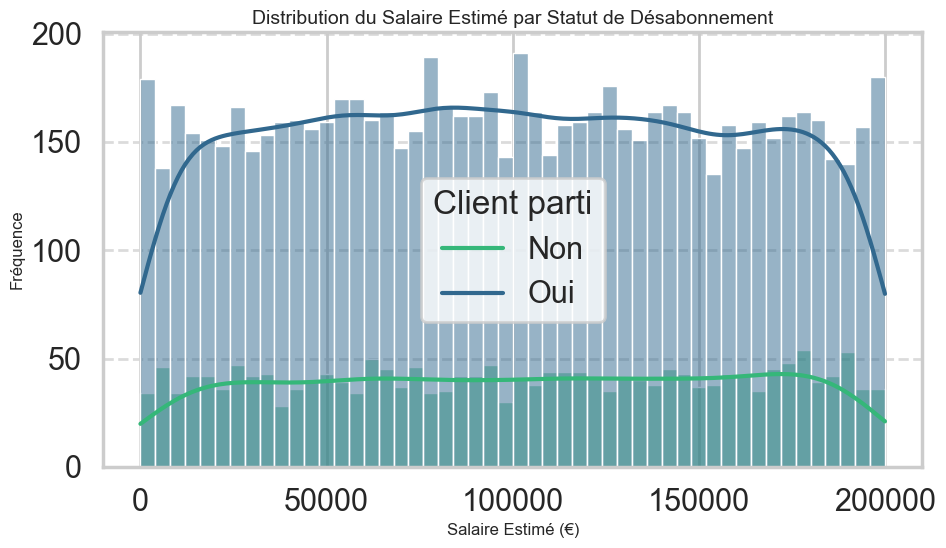


Graphique de distribution du Salaire Estimé généré : 'estimated_salary_distribution_by_churn.png'


In [ ]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    print("DataFrame 'df' chargé.")

# Création des histogrammes pour la distribution du EstimatedSalary
plt.figure(figsize=(10, 6))
# J'utilise la palette 'viridis' pour la cohérence des couleurs (Exited=0 vert/jaune, Exited=1 bleu/violet)
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', kde=True, palette='viridis', common_norm=False, bins=50)

plt.title('Distribution du Salaire Estimé par Statut de Désabonnement', fontsize=14)
plt.xlabel('Salaire Estimé (€)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend(title='Client parti', labels=['Non', 'Oui']) # Labels adaptés pour Exited (Non=0, Oui=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('estimated_salary_distribution_by_churn.png')
plt.show()

print("\nGraphique de distribution du Salaire Estimé généré : 'estimated_salary_distribution_by_churn.png'")

# Interprétation du Graphique du Salaire Estimé

1. Plage de Salaires et Distribution Générale

* Les salaires estimés s'étendent de 0 € à 200 000 € pour les deux groupes.

* Contrairement au solde (Balance) où nous avions un pic massif à 0, ici la distribution est beaucoup plus uniforme sur toute la plage de salaires pour les deux groupes. Il n'y a pas de "pic" unique prononcé. La fréquence reste relativement constante sur une large étendue des salaires.


2. Forme des Distributions

* Courbe bleue (Clients PARTIS) : elle commence à environ 80 fréquences à 0 €, monte à 150 fréquences vers 20 000 €, puis présente un effet de plateau autour de 160 000 € à 180 000 €, avant de redescendre à environ 80 fréquences vers 200 000 €.

* Courbe verte (Clients NON partis) : elle montre le "même phénomène mais beaucoup plus tassée", avec des fréquences plus faibles (environ 20 à 35) mais une forme similaire sur l'ensemble de la plage des salaires.


3. Comparaison des Densités / Fréquences

* La courbe bleue (clients partis) se situe systématiquement au-dessus de la courbe verte (clients non partis) sur l'ensemble de la plage des salaires. Cela signifie que, quel que soit le niveau de salaire estimé, la densité de clients qui partent est plus élevée que celle des clients qui restent, par rapport à la taille de leurs groupes respectifs.


Que pouvons-nous en déduire ?

1. Le Salaire Estimé ne semble PAS être un Facteur Discriminant Majeur en lui-même

* Contrairement à l'âge (où les âges plus avancés étaient clairement plus représentés chez les clients partis) ou au solde (où le fait d'avoir un solde non nul était très discriminant), le salaire estimé ne montre pas de pic spécifique ou de concentration particulière pour l'un ou l'autre groupe.

* Les deux groupes ont des clients répartis sur toute l'échelle des salaires. Il n'y a pas un "type de salaire" qui ferait qu'un client parte ou reste plus qu'un autre.


2. Une Proportionnalité qui pourrait être liée à la Taille des Groupes

> La courbe bleue (clients partis) étant globalement plus "haute" que la verte (non partis) sur l'ensemble du graphique pourrait simplement refléter une différence dans les tailles des groupes et la normalisation common_norm=False. C'est-à-dire que même si les clients partis sont moins nombreux, la densité de leurs salaires dans chaque bin est proportionnellement plus élevée.

* Cependant, l'absence de décalage ou de pic distinct pour l'un ou l'autre groupe suggère que le salaire estimé en tant que tel n'est pas un facteur de motivation ou de rétention fort. Les clients avec des salaires faibles partent au même rythme que ceux avec des salaires élevés, par rapport à leurs proportions dans chaque groupe.


En bref, visuellement, le salaire estimé semble avoir un impact bien moindre sur la probabilité de désabonnement que l'âge ou le fait d'avoir un solde bancaire. Nous confirmerons cette intuition avec un test statistique.

In [ ]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

In [34]:

try:
    df
except NameError:
    print("Le DataFrame 'df' n'est pas défini. Tentative de chargement du fichier CSV...")
    df = pd.read_csv("Churn_Modelling.csv")
    df_0 = df[df['Exited'] == 0] # Clients qui ne sont pas partis
    df_1 = df[df['Exited'] == 1] # Clients qui sont partis
    print("DataFrame 'df' chargé et 'df_0', 'df_1' créés.")

# Extraire les salaires estimés pour les deux groupes
estimated_salary_stayed = df_0['EstimatedSalary']
estimated_salary_exited = df_1['EstimatedSalary']

# Afficher les statistiques descriptives pour avoir une première idée
print(f"\nMoyenne Salaire Estimé (Clients restés) : {np.mean(estimated_salary_stayed):.2f}")
print(f"Écart-type Salaire Estimé (Clients restés) : {np.std(estimated_salary_stayed):.2f}")
print(f"\nMoyenne Salaire Estimé (Clients partis) : {np.mean(estimated_salary_exited):.2f}")
print(f"Écart-type Salaire Estimé (Clients partis) : {np.std(estimated_salary_exited):.2f}")

# Effectuer le test t de Student pour échantillons indépendants
# equal_var=False (Test de Welch) est fortement recommandé ici
t_statistic_salary, p_value_salary = stats.ttest_ind(estimated_salary_stayed, estimated_salary_exited, equal_var=False)

print(f"\n--- Résultat du Test t pour EstimatedSalary ---")
print(f"Statistique t : {t_statistic_salary:.3f}")
print(f"Valeur p : {p_value_salary:.3e}") # Affichage de la p-value en notation scientifique

# Interprétation du résultat (avec un seuil de signification alpha = 0.05)
alpha = 0.05
if p_value_salary < alpha:
    print("\nLa valeur p est inférieure au seuil de signification (0.05).")
    print("Nous rejetons l'hypothèse nulle.")
    print("Conclusion : Le salaire estimé des clients qui ont quitté la banque et de ceux qui ne l'ont pas fait n'est PAS similaire (il y a une différence statistiquement significative).")
else:
    print("\nLa valeur p est supérieure au seuil de signification (0.05).")
    print("Nous ne rejetons pas l'hypothèse nulle.")
    print("Conclusion : Le salaire estimé des clients qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).")


Moyenne Salaire Estimé (Clients restés) : 99738.39
Écart-type Salaire Estimé (Clients restés) : 57401.98

Moyenne Salaire Estimé (Clients partis) : 101465.68
Écart-type Salaire Estimé (Clients partis) : 57898.20

--- Résultat du Test t pour EstimatedSalary ---
Statistique t : -1.203
Valeur p : 2.289e-01

La valeur p est supérieure au seuil de signification (0.05).
Nous ne rejetons pas l'hypothèse nulle.
Conclusion : Le salaire estimé des clients qui ont quitté la banque et de celles qui ne l'ont pas fait est similaire (il n'y a pas de différence statistiquement significative).


# Observations

1. Statistiques Descriptives

* Moyenne Salaire Estimé (Clients restés) : 99 738,39 €

* Écart-type Salaire Estimé (Clients restés) : 57 401,98 €

* Moyenne Salaire Estimé (Clients partis) : 101 465,68 €

* Écart-type Salaire Estimé (Clients partis) : 57 898,20 €


En observant les moyennes, on constate qu'elles sont extrêmement proches. La différence n'est que d'environ 1 727 € (101 465,68 - 99 738,39), ce qui est minime par rapport à l'échelle des salaires. Les écarts-types sont également quasi identiques, ce qui indique une dispersion très similaire des salaires dans les deux groupes.


2. Résultat du Test t 

* Statistique t : -1.203

* Valeur p : 2.289e-01 (soit 0.2289)


3. Conclusion

* La p-value de 0.2289 est nettement supérieure à notre seuil de signification de 0.05.

* Par conséquent, nous ne rejetons pas l'hypothèse nulle.


Cela signifie que, sur la base de nos données, il n'y a pas de différence statistiquement significative dans le salaire estimé moyen entre les clients qui ont quitté la banque et ceux qui sont restés. La petite différence observée entre les moyennes est très probablement due au hasard de l'échantillonnage et ne reflète pas une vraie différence dans la population de tous les clients.


Réconciliation avec l'Observation Visuelle
Ce résultat statistique confirme parfaitement notre déduction visuelle de l'histogramme du salaire estimé. Nous avions noté que les courbes étaient "homothétiques" et "beaucoup plus tassées" (pour le groupe des non-partants), mais sans pic distinct ou décalage clair entre les groupes. L'absence de différence statistiquement significative soutient cette observation : le salaire estimé ne semble pas être un facteur clé de distinction entre les clients qui restent et ceux qui partent.


= En conclusion pour le Estimated Salary =

Le salaire estimé n'apparaît pas comme un prédicteur significatif du désabonnement des clients. Les clients ayant un salaire élevé ne sont pas plus ou moins susceptibles de partir que ceux ayant un salaire faible. Ce facteur semble jouer un rôle négligeable dans la décision de quitter la banque, du moins en tant que variable unique.

### Using Bootstrapping

In [ ]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

In [ ]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

In [ ]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Final Conclusion
What will be the most helpful feature in predicting churning?
